In [1]:
!pip install yfinance pyts tensorflow scikit-learn statsmodels matplotlib seaborn pandas numpy reportlab -q

print("=" * 60)
print("PACKAGE INSTALLATION COMPLETE")
print("=" * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 51.6 MB/s eta 0:00:00
PACKAGE INSTALLATION COMPLETE


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
import random
random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

# Import statistical and ML libraries
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from pyts.image import GramianAngularField

print("=" * 60)
print("ALL LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 60)
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Random seeds set to: 42")

ALL LIBRARIES IMPORTED SUCCESSFULLY
NumPy version: 2.0.2
Pandas version: 2.2.2
TensorFlow version: 2.19.0
Random seeds set to: 42


In [3]:
# Download BTC-USD data from Yahoo Finance
print("Downloading BTC-USD data from Yahoo Finance...")
df = yf.download("BTC-USD", start="2018-01-01", end="2023-06-01", auto_adjust=True, progress=False)

# Handle MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

close = df["Close"].dropna()
close = close.iloc[:2000]

# Verify data quality
if len(close) < 500:
    raise ValueError(f"ERROR: Only {len(close)} rows downloaded. Check internet connection or yfinance version.")

print(f"\nTicker: BTC-USD | Rows loaded: {len(close)} | From: {close.index[0].date()} | To: {close.index[-1].date()}")
print(f"Data range: {close.min():.2f} to {close.max():.2f}")
print("\nFirst 5 observations:")
print(close.head())


Ticker: BTC-USD | Rows loaded: 1977 | From: 2018-01-01 | To: 2023-05-31
Data range: 3236.76 to 67566.83

First 5 observations:
Date
2018-01-01    13657.200195
2018-01-02    14982.099609
2018-01-03    15201.000000
2018-01-04    15599.200195
2018-01-05    17429.500000
Name: Close, dtype: float64


# Step 1: Time Series Analysis

## Step 1a: Raw Price Series (Levels)

STEP 1a: RAW PRICE SERIES (LEVELS) ANALYSIS
Saved: fig_01_price_levels.png


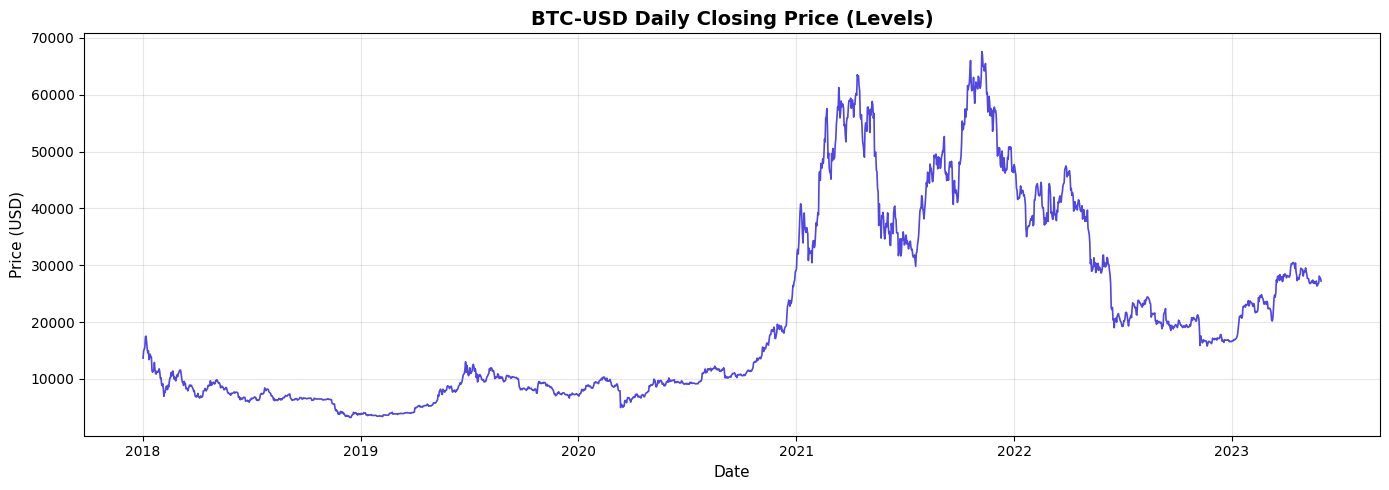


Summary Statistics - Price Levels:
                      Value
Mean             20695.7703
Median           11805.6533
Std Dev          16401.3527
Skewness             0.9921
Kurtosis            -0.2058
Min               3236.7617
Max              67566.8281
25th Percentile   8027.2681
75th Percentile  30825.6992
Saved: fig_02_price_histogram.png


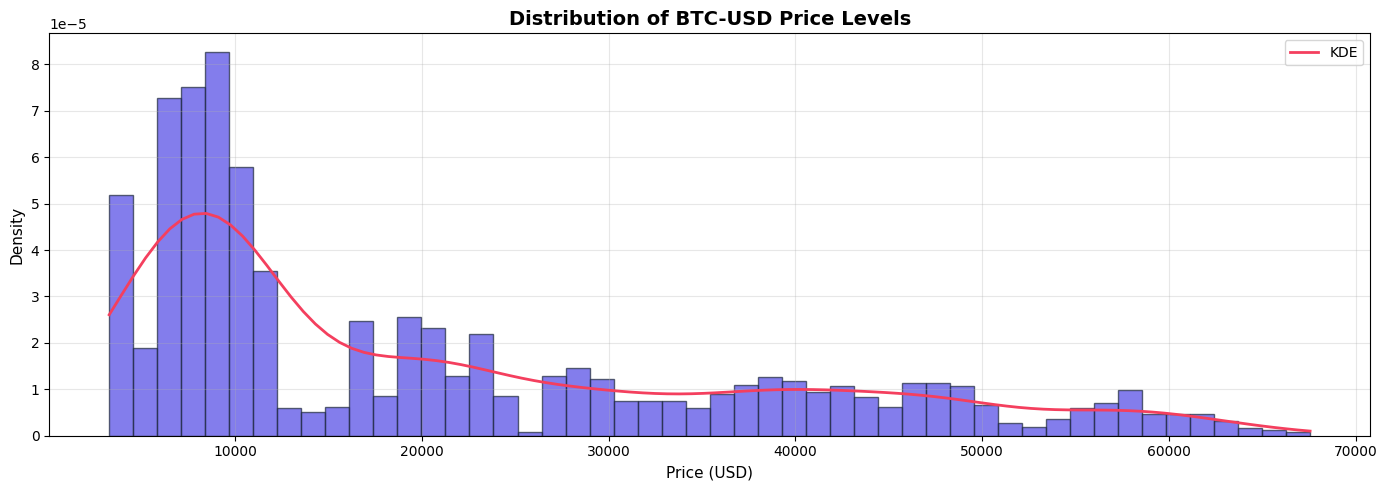

Saved: fig_03_price_acf_pacf.png


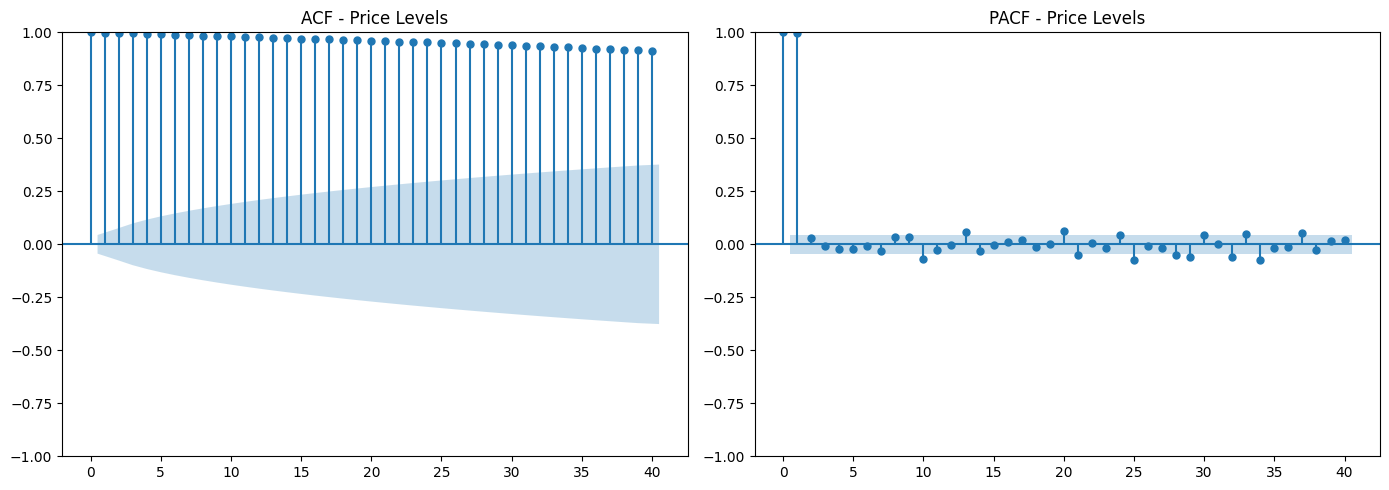


AUGMENTED DICKEY-FULLER TEST - PRICE LEVELS
Test Statistic: -1.423500
p-value: 0.570960
Critical Values:
	1%: -3.433704
	5%: -2.863022
	10%: -2.567559

Conclusion: Series is NON-STATIONARY (fail to reject null hypothesis)


In [4]:
# Step 1a: Raw Price Series Analysis
print("=" * 60)
print("STEP 1a: RAW PRICE SERIES (LEVELS) ANALYSIS")
print("=" * 60)

# Plot price levels
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(close.index, close.values, linewidth=1.2, color='#4F46E5')
ax.set_title('BTC-USD Daily Closing Price (Levels)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Price (USD)', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_01_price_levels.png', bbox_inches='tight', dpi=150)
print("Saved: fig_01_price_levels.png")
plt.show()

# Summary statistics
from scipy import stats
summary_levels = {
    'Mean': close.mean(),
    'Median': close.median(),
    'Std Dev': close.std(),
    'Skewness': stats.skew(close),
    'Kurtosis': stats.kurtosis(close),
    'Min': close.min(),
    'Max': close.max(),
    '25th Percentile': close.quantile(0.25),
    '75th Percentile': close.quantile(0.75)
}
df_summary_levels = pd.DataFrame([summary_levels]).T
df_summary_levels.columns = ['Value']
print("\nSummary Statistics - Price Levels:")
print(df_summary_levels.round(4))

# Histogram
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(close.values, bins=50, density=True, alpha=0.7, color='#4F46E5', edgecolor='#1E293B')
# Add KDE
from scipy.stats import gaussian_kde
kde = gaussian_kde(close.values)
x_range = np.linspace(close.min(), close.max(), 100)
ax.plot(x_range, kde(x_range), '#F43F5E', linewidth=2, label='KDE')
ax.set_title('Distribution of BTC-USD Price Levels', fontsize=14, fontweight='bold')
ax.set_xlabel('Price (USD)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_02_price_histogram.png', bbox_inches='tight', dpi=150)
print("Saved: fig_02_price_histogram.png")
plt.show()

# ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(close.values, lags=40, ax=axes[0], title='ACF - Price Levels')
plot_pacf(close.values, lags=40, ax=axes[1], title='PACF - Price Levels', method='ywm')
plt.tight_layout()
plt.savefig('fig_03_price_acf_pacf.png', bbox_inches='tight', dpi=150)
print("Saved: fig_03_price_acf_pacf.png")
plt.show()

# ADF Test
adf_result = adfuller(close.values)
print("\n" + "=" * 60)
print("AUGMENTED DICKEY-FULLER TEST - PRICE LEVELS")
print("=" * 60)
print(f"Test Statistic: {adf_result[0]:.6f}")
print(f"p-value: {adf_result[1]:.6f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"\t{key}: {value:.6f}")
if adf_result[1] < 0.05:
    print("\nConclusion: Series is STATIONARY (reject null hypothesis)")
else:
    print("\nConclusion: Series is NON-STATIONARY (fail to reject null hypothesis)")

# Store for later comparison
adf_levels = adf_result

## Step 1b: Stationary Transformation (Log-Returns)

STEP 1b: LOG-RETURNS ANALYSIS
Log-returns computed: 1976 observations
Saved: fig_04_logreturns_series.png


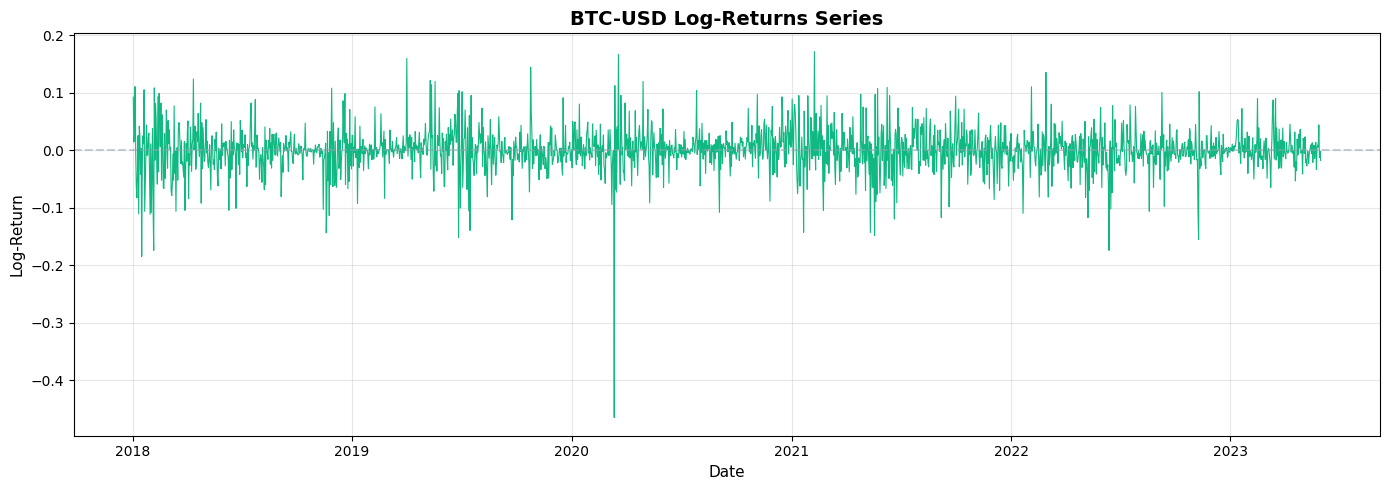


Summary Statistics - Log-Returns:
                     Value
Mean              0.000349
Median            0.000870
Std Dev           0.038164
Skewness         -1.049240
Kurtosis         13.478607
Min              -0.464730
Max               0.171821
25th Percentile  -0.015217
75th Percentile   0.017054
Saved: fig_05_logreturns_histogram.png


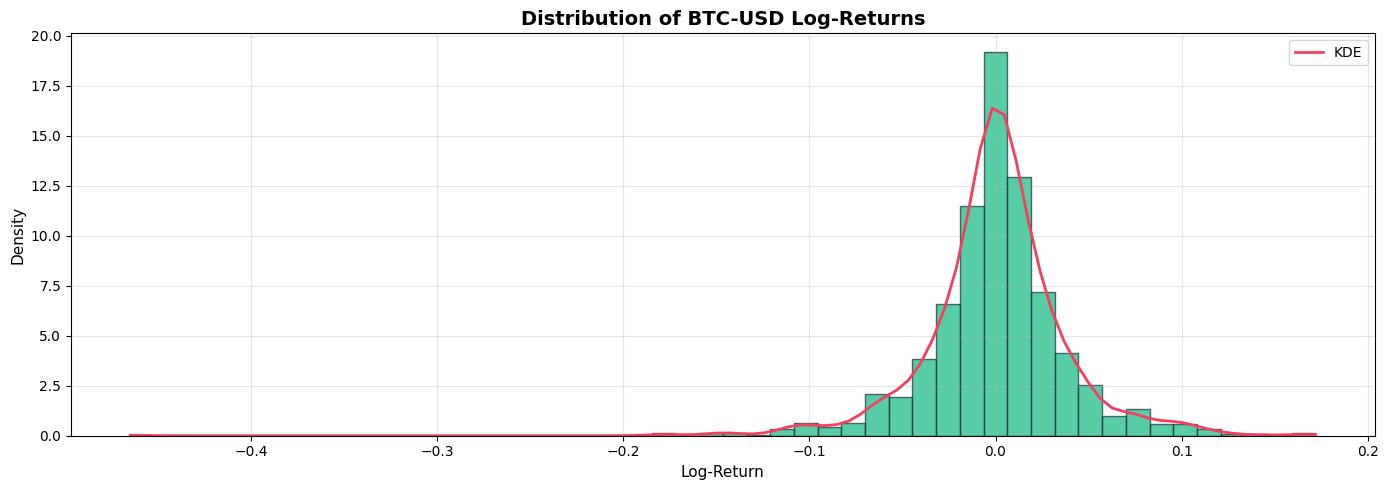

Saved: fig_06_logreturns_acf_pacf.png


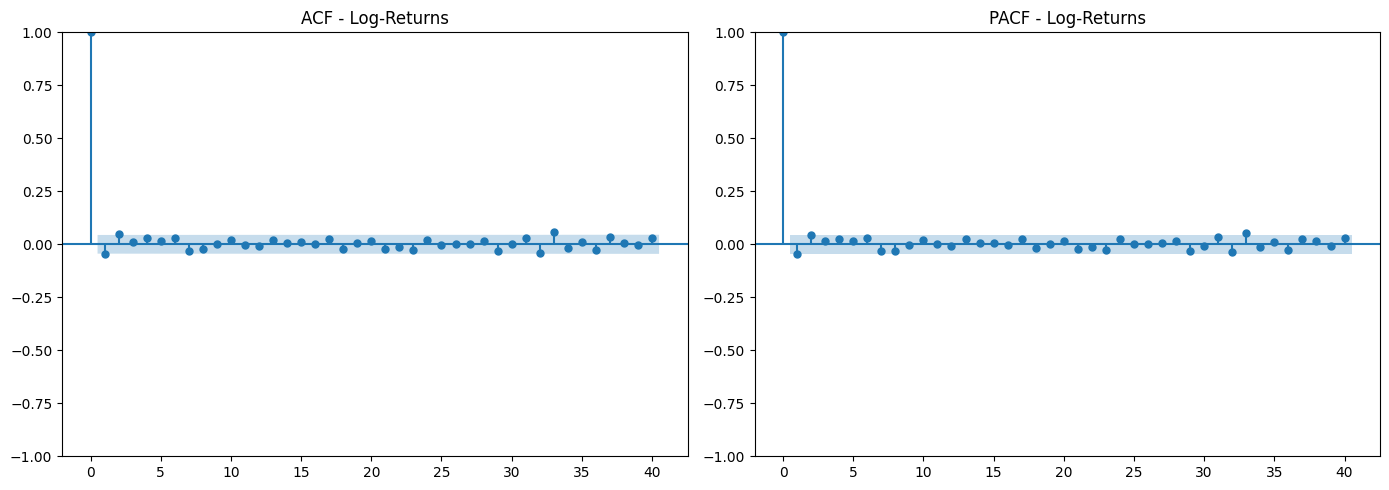


AUGMENTED DICKEY-FULLER TEST - LOG-RETURNS
Test Statistic: -30.714218
p-value: 0.000000
Critical Values:
	1%: -3.433667
	5%: -2.863005
	10%: -2.567550

Conclusion: Series is STATIONARY (reject null hypothesis)


In [5]:
# Step 1b: Log-Returns Analysis
print("=" * 60)
print("STEP 1b: LOG-RETURNS ANALYSIS")
print("=" * 60)

# Compute log-returns
log_returns = np.log(close / close.shift(1)).dropna()
print(f"Log-returns computed: {len(log_returns)} observations")

# Plot log-returns
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(log_returns.index, log_returns.values, linewidth=0.8, color='#10B981')
ax.set_title('BTC-USD Log-Returns Series', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Log-Return', fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='#94A3B8', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_04_logreturns_series.png', bbox_inches='tight', dpi=150)
print("Saved: fig_04_logreturns_series.png")
plt.show()

# Summary statistics for log-returns
summary_logret = {
    'Mean': log_returns.mean(),
    'Median': log_returns.median(),
    'Std Dev': log_returns.std(),
    'Skewness': stats.skew(log_returns),
    'Kurtosis': stats.kurtosis(log_returns),
    'Min': log_returns.min(),
    'Max': log_returns.max(),
    '25th Percentile': log_returns.quantile(0.25),
    '75th Percentile': log_returns.quantile(0.75)
}
df_summary_logret = pd.DataFrame([summary_logret]).T
df_summary_logret.columns = ['Value']
print("\nSummary Statistics - Log-Returns:")
print(df_summary_logret.round(6))

# Histogram of log-returns
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(log_returns.values, bins=50, density=True, alpha=0.7, color='#10B981', edgecolor='#1E293B')
# Add KDE
kde_lr = gaussian_kde(log_returns.values)
x_range_lr = np.linspace(log_returns.min(), log_returns.max(), 100)
ax.plot(x_range_lr, kde_lr(x_range_lr), '#F43F5E', linewidth=2, label='KDE')
ax.set_title('Distribution of BTC-USD Log-Returns', fontsize=14, fontweight='bold')
ax.set_xlabel('Log-Return', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_05_logreturns_histogram.png', bbox_inches='tight', dpi=150)
print("Saved: fig_05_logreturns_histogram.png")
plt.show()

# ACF and PACF for log-returns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(log_returns.values, lags=40, ax=axes[0], title='ACF - Log-Returns')
plot_pacf(log_returns.values, lags=40, ax=axes[1], title='PACF - Log-Returns', method='ywm')
plt.tight_layout()
plt.savefig('fig_06_logreturns_acf_pacf.png', bbox_inches='tight', dpi=150)
print("Saved: fig_06_logreturns_acf_pacf.png")
plt.show()

# ADF Test for log-returns
adf_logret = adfuller(log_returns.values)
print("\n" + "=" * 60)
print("AUGMENTED DICKEY-FULLER TEST - LOG-RETURNS")
print("=" * 60)
print(f"Test Statistic: {adf_logret[0]:.6f}")
print(f"p-value: {adf_logret[1]:.6f}")
print("Critical Values:")
for key, value in adf_logret[4].items():
    print(f"\t{key}: {value:.6f}")
if adf_logret[1] < 0.05:
    print("\nConclusion: Series is STATIONARY (reject null hypothesis)")
else:
    print("\nConclusion: Series is NON-STATIONARY (fail to reject null hypothesis)")

## Step 1c: Fractional Differencing

STEP 1c: FRACTIONAL DIFFERENCING
Searching for optimal d* (ADF test for each d value)...
Saved: fig_10_fracdiff_d_search.png


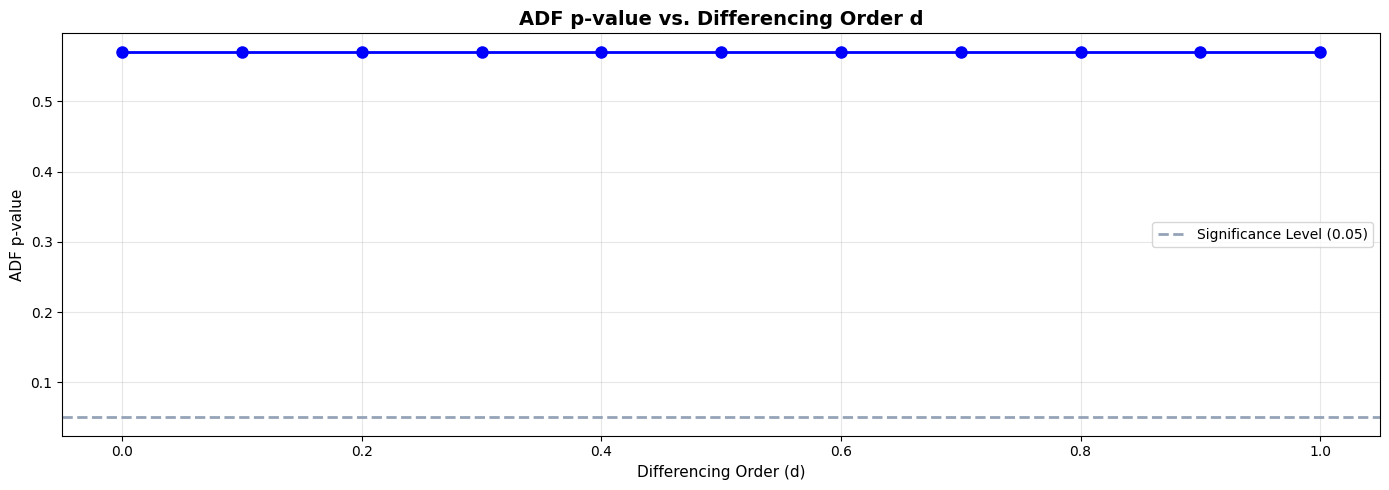


Optimal d* = 1.0
ADF p-value at d* = 0.570960
Fractionally differenced series: 1977 observations


In [6]:
# Step 1c: Fractional Differencing Implementation
print("=" * 60)
print("STEP 1c: FRACTIONAL DIFFERENCING")
print("=" * 60)

def get_weights(d, size):
    """Generate weights for fractional differencing using fixed-width window."""
    w = [1.0]
    for k in range(1, size):
        w.append(-w[-1] * (d - k + 1) / k)
    return np.array(w)

def frac_diff_fixed_window(series, d, threshold=1e-5):
    """Apply fractional differencing with fixed-width window."""
    n = len(series)
    weights = get_weights(d, n)

    # Find effective window where weights are significant
    weights = weights[weights > threshold]
    width = len(weights)

    # Apply convolution
    result = np.zeros(n)
    result[:] = np.nan

    for i in range(width - 1, n):
        result[i] = np.dot(weights[::-1], series[i - width + 1:i + 1])

    return result

# Search for optimal d* from 0.0 to 1.0 in steps of 0.1
d_values = np.arange(0.0, 1.1, 0.1)
adf_pvalues = []
adf_stats = []

print("Searching for optimal d* (ADF test for each d value)...")
for d in d_values:
    frac_series = frac_diff_fixed_window(close.values, d)
    frac_series_clean = frac_series[~np.isnan(frac_series)]
    if len(frac_series_clean) > 100:
        adf_res = adfuller(frac_series_clean)
        adf_pvalues.append(adf_res[1])
        adf_stats.append(adf_res[0])
    else:
        adf_pvalues.append(np.nan)
        adf_stats.append(np.nan)

# Plot ADF p-value vs d
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(d_values, adf_pvalues, 'bo-', linewidth=2, markersize=8)
ax.axhline(y=0.05, color='#94A3B8', linestyle='--', linewidth=2, label='Significance Level (0.05)')
ax.set_xlabel('Differencing Order (d)', fontsize=11)
ax.set_ylabel('ADF p-value', fontsize=11)
ax.set_title('ADF p-value vs. Differencing Order d', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('fig_10_fracdiff_d_search.png', bbox_inches='tight', dpi=150)
print("Saved: fig_10_fracdiff_d_search.png")
plt.show()

# Find optimal d* (minimum d such that p-value < 0.05)
optimal_d = None
for i, (d, pval) in enumerate(zip(d_values, adf_pvalues)):
    if pval < 0.05:
        optimal_d = d
        break

if optimal_d is None:
    optimal_d = 1.0  # Default to full differencing if no stationarity achieved

print(f"\nOptimal d* = {optimal_d}")
print(f"ADF p-value at d* = {adf_pvalues[int(optimal_d * 10)]:.6f}")

# Apply fractional differencing with optimal d*
frac_diff_series = frac_diff_fixed_window(close.values, optimal_d)
frac_diff_clean = frac_diff_series[~np.isnan(frac_diff_series)]
frac_diff_index = close.index[-len(frac_diff_clean):]
frac_diff_series = pd.Series(frac_diff_clean, index=frac_diff_index)

print(f"Fractionally differenced series: {len(frac_diff_series)} observations")

Saved: fig_07_fracdiff_series.png


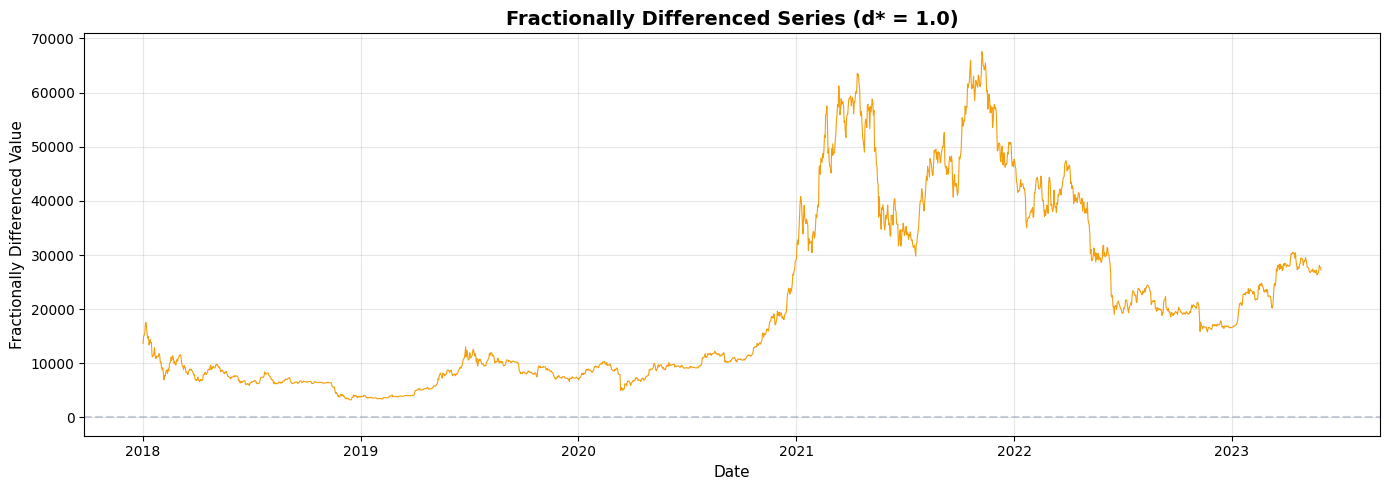


Summary Statistics - Fractionally Differenced Series:
                        Value
Mean             20695.770283
Median           11805.653320
Std Dev          16401.352697
Skewness             0.992121
Kurtosis            -0.205821
Min               3236.761719
Max              67566.828125
25th Percentile   8027.268066
75th Percentile  30825.699219
Saved: fig_08_fracdiff_histogram.png


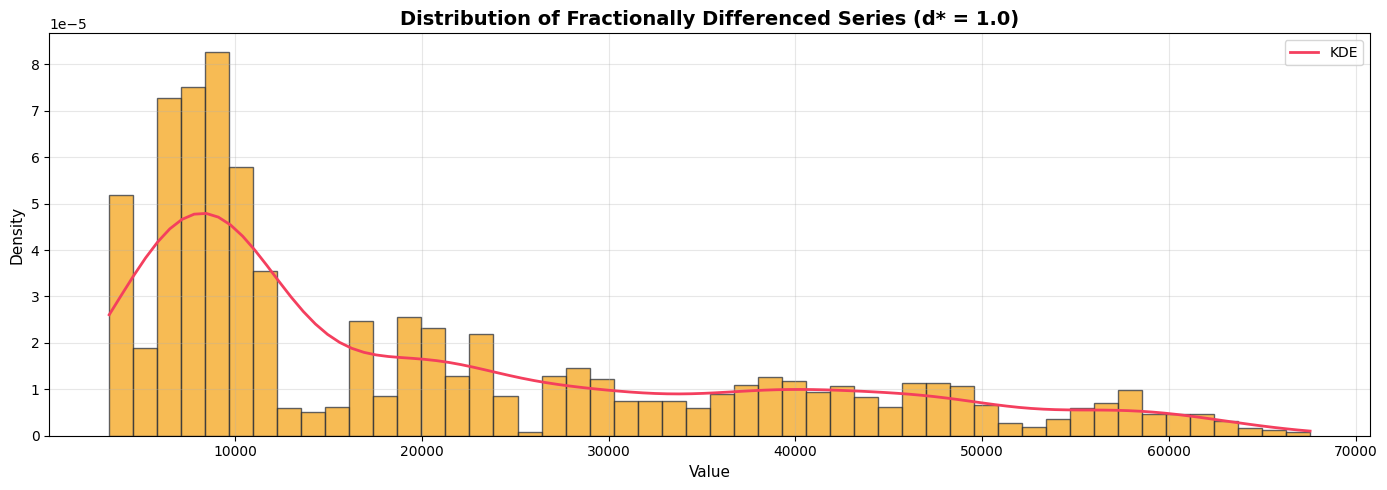

Saved: fig_09_fracdiff_acf_pacf.png


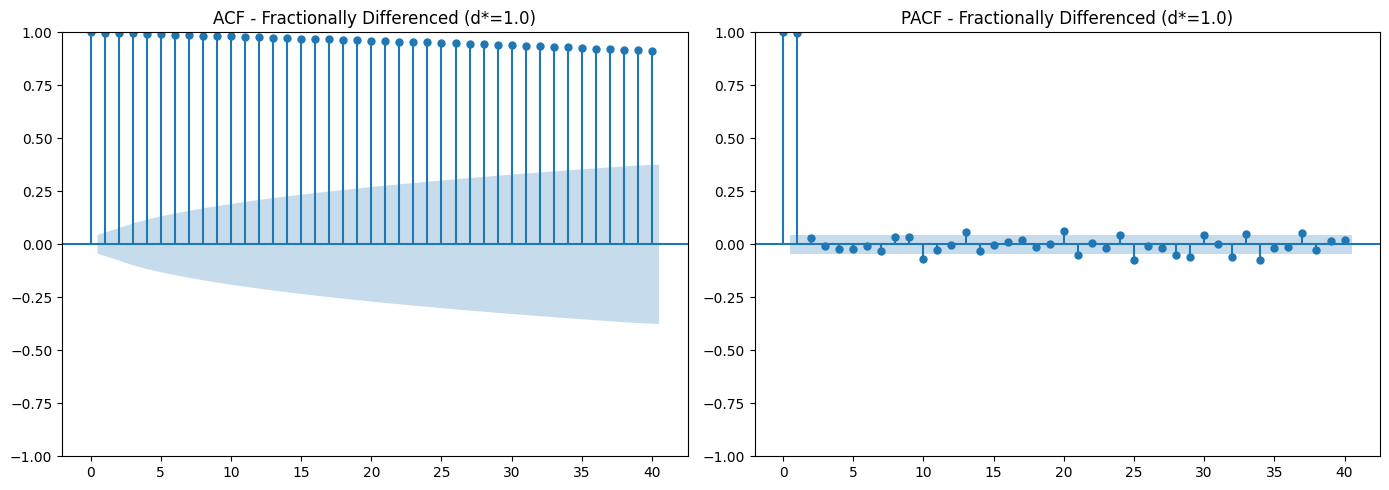


AUGMENTED DICKEY-FULLER TEST - FRACTIONALLY DIFFERENCED
Test Statistic: -1.423500
p-value: 0.570960
Critical Values:
	1%: -3.433704
	5%: -2.863022
	10%: -2.567559

Conclusion: Series is NON-STATIONARY (fail to reject null hypothesis)

Correlation with original price levels: 1.000000


In [7]:
# Plot fractionally differenced series
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(frac_diff_series.index, frac_diff_series.values, linewidth=0.8, color='#F59E0B')
ax.set_title(f'Fractionally Differenced Series (d* = {optimal_d})', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Fractionally Differenced Value', fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='#94A3B8', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_07_fracdiff_series.png', bbox_inches='tight', dpi=150)
print("Saved: fig_07_fracdiff_series.png")
plt.show()

# Summary statistics for fractionally differenced series
summary_frac = {
    'Mean': frac_diff_series.mean(),
    'Median': frac_diff_series.median(),
    'Std Dev': frac_diff_series.std(),
    'Skewness': stats.skew(frac_diff_series),
    'Kurtosis': stats.kurtosis(frac_diff_series),
    'Min': frac_diff_series.min(),
    'Max': frac_diff_series.max(),
    '25th Percentile': frac_diff_series.quantile(0.25),
    '75th Percentile': frac_diff_series.quantile(0.75)
}
df_summary_frac = pd.DataFrame([summary_frac]).T
df_summary_frac.columns = ['Value']
print("\nSummary Statistics - Fractionally Differenced Series:")
print(df_summary_frac.round(6))

# Histogram of fractionally differenced series
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(frac_diff_series.values, bins=50, density=True, alpha=0.7, color='#F59E0B', edgecolor='#1E293B')
# Add KDE
kde_frac = gaussian_kde(frac_diff_series.values)
x_range_frac = np.linspace(frac_diff_series.min(), frac_diff_series.max(), 100)
ax.plot(x_range_frac, kde_frac(x_range_frac), '#F43F5E', linewidth=2, label='KDE')
ax.set_title(f'Distribution of Fractionally Differenced Series (d* = {optimal_d})', fontsize=14, fontweight='bold')
ax.set_xlabel('Value', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_08_fracdiff_histogram.png', bbox_inches='tight', dpi=150)
print("Saved: fig_08_fracdiff_histogram.png")
plt.show()

# ACF and PACF for fractionally differenced series
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(frac_diff_series.values, lags=40, ax=axes[0], title=f'ACF - Fractionally Differenced (d*={optimal_d})')
plot_pacf(frac_diff_series.values, lags=40, ax=axes[1], title=f'PACF - Fractionally Differenced (d*={optimal_d})', method='ywm')
plt.tight_layout()
plt.savefig('fig_09_fracdiff_acf_pacf.png', bbox_inches='tight', dpi=150)
print("Saved: fig_09_fracdiff_acf_pacf.png")
plt.show()

# ADF Test for fractionally differenced series
adf_frac = adfuller(frac_diff_series.values)
print("\n" + "=" * 60)
print("AUGMENTED DICKEY-FULLER TEST - FRACTIONALLY DIFFERENCED")
print("=" * 60)
print(f"Test Statistic: {adf_frac[0]:.6f}")
print(f"p-value: {adf_frac[1]:.6f}")
print("Critical Values:")
for key, value in adf_frac[4].items():
    print(f"\t{key}: {value:.6f}")
if adf_frac[1] < 0.05:
    print("\nConclusion: Series is STATIONARY (reject null hypothesis)")
else:
    print("\nConclusion: Series is NON-STATIONARY (fail to reject null hypothesis)")

# Correlation with original price levels
# Align the series for correlation calculation
frac_diff_aligned = frac_diff_series.reindex(close.index)
correlation_with_levels = frac_diff_aligned.corr(close)
print(f"\nCorrelation with original price levels: {correlation_with_levels:.6f}")

## Step 1d: Comparative Commentary on Three Representations

# Step 2: Multi-Layer Perceptron (MLP) Models

## Step 2a: MLP on Price Levels

In [8]:
# Initialize metrics dictionaries
mlp_metrics = {}
cnn_metrics = {}

# Step 2a: MLP on Price Levels
print("=" * 60)
print("STEP 2a: MLP MODEL ON PRICE LEVELS")
print("=" * 60)

def create_mlp_data(series, window_size=10):
    """Create supervised learning data from time series."""
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size])
    return np.array(X), np.array(y)

# Prepare data for levels
window_size = 10
X_levels, y_levels = create_mlp_data(close.values, window_size)
print(f"Input shape: {X_levels.shape}, Target shape: {y_levels.shape}")

# Train-test split (80/20, preserving time order)
split_idx = int(0.8 * len(X_levels))
X_train_levels, X_test_levels = X_levels[:split_idx], X_levels[split_idx:]
y_train_levels, y_test_levels = y_levels[:split_idx], y_levels[split_idx:]

# Scale data
scaler_levels_X = MinMaxScaler()
scaler_levels_y = MinMaxScaler()
X_train_levels_scaled = scaler_levels_X.fit_transform(X_train_levels)
X_test_levels_scaled = scaler_levels_X.transform(X_test_levels)
y_train_levels_scaled = scaler_levels_y.fit_transform(y_train_levels.reshape(-1, 1)).flatten()
y_test_levels_scaled = scaler_levels_y.transform(y_test_levels.reshape(-1, 1)).flatten()

print(f"Training samples: {len(X_train_levels_scaled)}, Test samples: {len(X_test_levels_scaled)}")

# Build MLP model
mlp_levels = Sequential([
    Dense(64, activation='relu', input_shape=(window_size,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
])

mlp_levels.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
print("\nMLP Model Architecture (Levels):")
mlp_levels.summary()

# Train model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_levels = mlp_levels.fit(
    X_train_levels_scaled, y_train_levels_scaled,
    epochs=50, batch_size=32, validation_split=0.1,
    callbacks=[early_stop], verbose=0
)

print(f"\nTraining completed. Best epoch: {np.argmin(history_levels.history['val_loss']) + 1}")

STEP 2a: MLP MODEL ON PRICE LEVELS
Input shape: (1967, 10), Target shape: (1967,)
Training samples: 1573, Test samples: 394

MLP Model Architecture (Levels):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)


Training completed. Best epoch: 15


Saved: fig_11_mlp_levels_loss.png


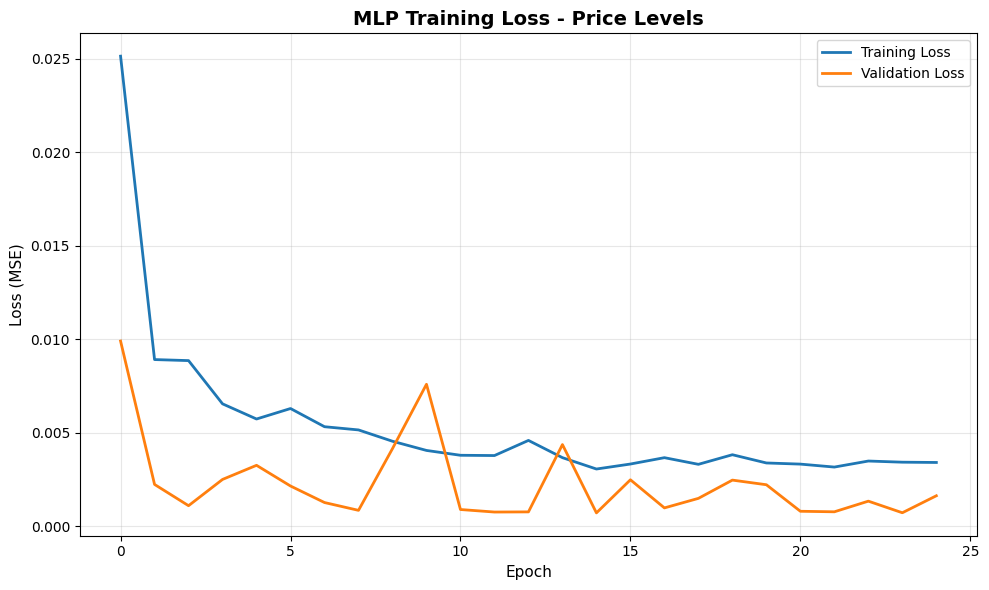

Saved: fig_12_mlp_levels_predictions.png


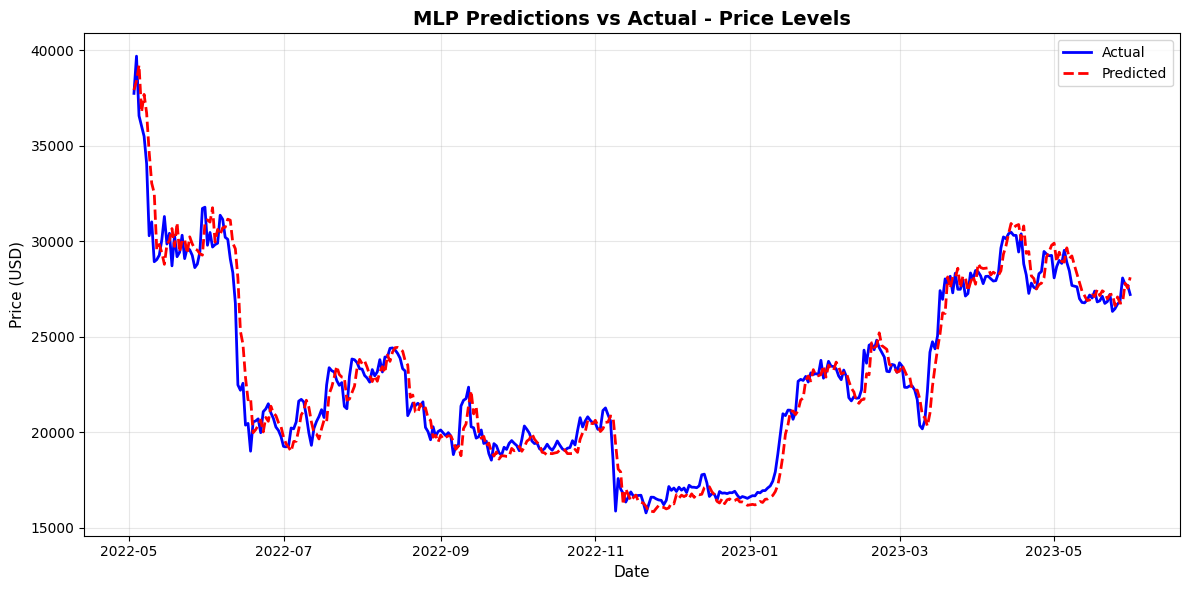


MLP PERFORMANCE METRICS - PRICE LEVELS
MSE:  984,349.39
RMSE: 992.14
MAE:  692.33
R-squared: 0.954119


In [ ]:
# Plot loss curve
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(history_levels.history['loss'], label='Training Loss', linewidth=2)
ax.plot(history_levels.history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss (MSE)', fontsize=11)
ax.set_title('MLP Training Loss - Price Levels', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_11_mlp_levels_loss.png', bbox_inches='tight', dpi=150)
print("Saved: fig_11_mlp_levels_loss.png")
plt.show()

# Make predictions
y_pred_levels_scaled = mlp_levels.predict(X_test_levels_scaled, verbose=0).flatten()
y_pred_levels = scaler_levels_y.inverse_transform(y_pred_levels_scaled.reshape(-1, 1)).flatten()

# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(14, 5))
test_index = close.index[split_idx + window_size:split_idx + window_size + len(y_test_levels)]
ax.plot(test_index, y_test_levels, label='Actual', linewidth=2, color='#4F46E5')
ax.plot(test_index, y_pred_levels, label='Predicted', linewidth=2, color='#F43F5E', linestyle='--')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Price (USD)', fontsize=11)
ax.set_title('MLP Predictions vs Actual - Price Levels', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_12_mlp_levels_predictions.png', bbox_inches='tight', dpi=150)
print("Saved: fig_12_mlp_levels_predictions.png")
plt.show()

# Calculate metrics
mse_levels = mean_squared_error(y_test_levels, y_pred_levels)
rmse_levels = np.sqrt(mse_levels)
mae_levels = mean_absolute_error(y_test_levels, y_pred_levels)
r2_levels = r2_score(y_test_levels, y_pred_levels)

print("\n" + "=" * 60)
print("MLP PERFORMANCE METRICS - PRICE LEVELS")
print("=" * 60)
print(f"MSE:  {mse_levels:,.2f}")
print(f"RMSE: {rmse_levels:,.2f}")
print(f"MAE:  {mae_levels:,.2f}")
print(f"R-squared: {r2_levels:.6f}")

# Store metrics for comparison
mlp_metrics = {
    'Levels': {'MSE': mse_levels, 'RMSE': rmse_levels, 'MAE': mae_levels, 'R2': r2_levels}
}

## Step 2b: MLP on Log-Returns

STEP 2b: MLP MODEL ON LOG-RETURNS
Input shape: (1966, 10), Target shape: (1966,)
Training samples: 1572, Test samples: 394
Training completed. Best epoch: 3
Saved: fig_13_mlp_stationary_loss.png


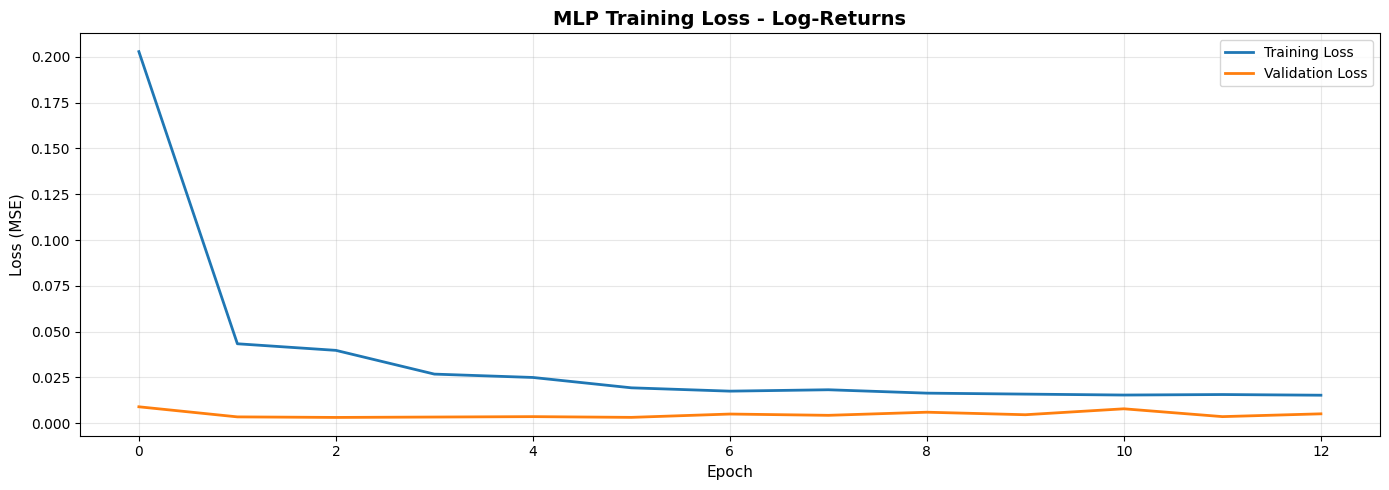

Saved: fig_14_mlp_stationary_predictions.png


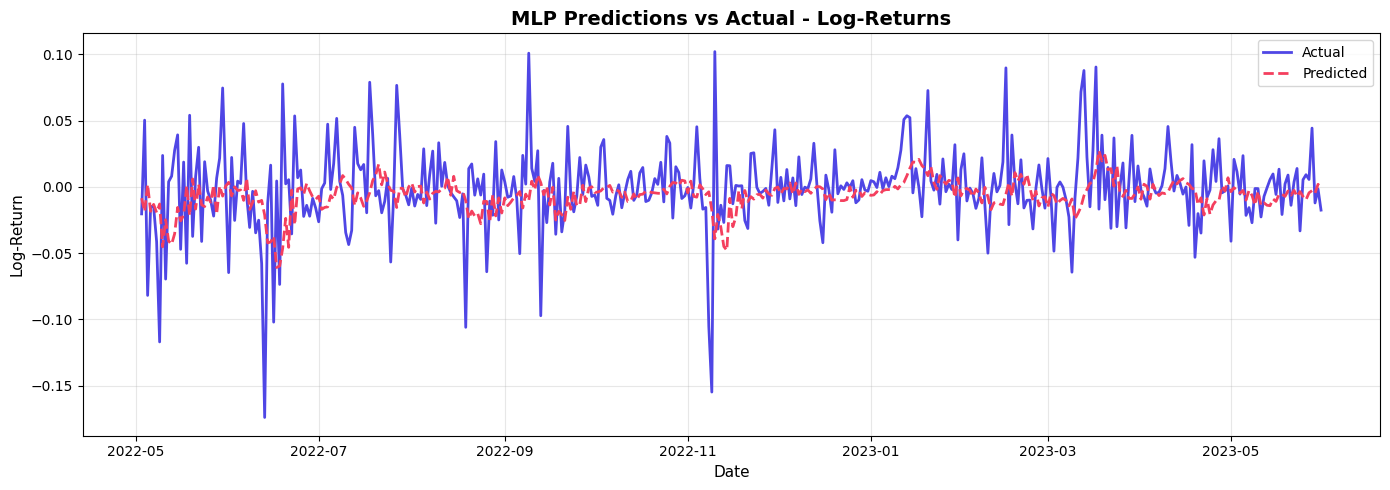


MLP PERFORMANCE METRICS - LOG-RETURNS
MSE:  0.00112716
RMSE: 0.033573
MAE:  0.023547
R-squared: -0.161982


In [9]:
# Step 2b: MLP on Log-Returns
print("=" * 60)
print("STEP 2b: MLP MODEL ON LOG-RETURNS")
print("=" * 60)

# Prepare data for log-returns
X_logret, y_logret = create_mlp_data(log_returns.values, window_size)
print(f"Input shape: {X_logret.shape}, Target shape: {y_logret.shape}")

# Train-test split
split_idx_lr = int(0.8 * len(X_logret))
X_train_logret, X_test_logret = X_logret[:split_idx_lr], X_logret[split_idx_lr:]
y_train_logret, y_test_logret = y_logret[:split_idx_lr], y_logret[split_idx_lr:]

# Scale data
scaler_logret_X = MinMaxScaler()
scaler_logret_y = MinMaxScaler()
X_train_logret_scaled = scaler_logret_X.fit_transform(X_train_logret)
X_test_logret_scaled = scaler_logret_X.transform(X_test_logret)
y_train_logret_scaled = scaler_logret_y.fit_transform(y_train_logret.reshape(-1, 1)).flatten()
y_test_logret_scaled = scaler_logret_y.transform(y_test_logret.reshape(-1, 1)).flatten()

print(f"Training samples: {len(X_train_logret_scaled)}, Test samples: {len(X_test_logret_scaled)}")

# Build MLP model (same architecture)
mlp_logret = Sequential([
    Dense(64, activation='relu', input_shape=(window_size,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
])

mlp_logret.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# Train model
history_logret = mlp_logret.fit(
    X_train_logret_scaled, y_train_logret_scaled,
    epochs=50, batch_size=32, validation_split=0.1,
    callbacks=[early_stop], verbose=0
)

print(f"Training completed. Best epoch: {np.argmin(history_logret.history['val_loss']) + 1}")

# Plot loss curve
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(history_logret.history['loss'], label='Training Loss', linewidth=2)
ax.plot(history_logret.history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss (MSE)', fontsize=11)
ax.set_title('MLP Training Loss - Log-Returns', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_13_mlp_stationary_loss.png', bbox_inches='tight', dpi=150)
print("Saved: fig_13_mlp_stationary_loss.png")
plt.show()

# Make predictions
y_pred_logret_scaled = mlp_logret.predict(X_test_logret_scaled, verbose=0).flatten()
y_pred_logret = scaler_logret_y.inverse_transform(y_pred_logret_scaled.reshape(-1, 1)).flatten()

# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(14, 5))
test_index_lr = log_returns.index[split_idx_lr + window_size:split_idx_lr + window_size + len(y_test_logret)]
ax.plot(test_index_lr, y_test_logret, label='Actual', linewidth=2, color='#4F46E5')
ax.plot(test_index_lr, y_pred_logret, label='Predicted', linewidth=2, color='#F43F5E', linestyle='--')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Log-Return', fontsize=11)
ax.set_title('MLP Predictions vs Actual - Log-Returns', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_14_mlp_stationary_predictions.png', bbox_inches='tight', dpi=150)
print("Saved: fig_14_mlp_stationary_predictions.png")
plt.show()

# Calculate metrics
mse_logret = mean_squared_error(y_test_logret, y_pred_logret)
rmse_logret = np.sqrt(mse_logret)
mae_logret = mean_absolute_error(y_test_logret, y_pred_logret)
r2_logret = r2_score(y_test_logret, y_pred_logret)

print("\n" + "=" * 60)
print("MLP PERFORMANCE METRICS - LOG-RETURNS")
print("=" * 60)
print(f"MSE:  {mse_logret:.8f}")
print(f"RMSE: {rmse_logret:.6f}")
print(f"MAE:  {mae_logret:.6f}")
print(f"R-squared: {r2_logret:.6f}")

# Store metrics
mlp_metrics['Log-Returns'] = {'MSE': mse_logret, 'RMSE': rmse_logret, 'MAE': mae_logret, 'R2': r2_logret}

## Step 2c: MLP on Fractionally Differenced Series

STEP 2c: MLP MODEL ON FRACTIONALLY DIFFERENCED SERIES
Input shape: (1967, 10), Target shape: (1967,)
Training samples: 1573, Test samples: 394
Training completed. Best epoch: 2
Saved: fig_15_mlp_fracdiff_loss.png


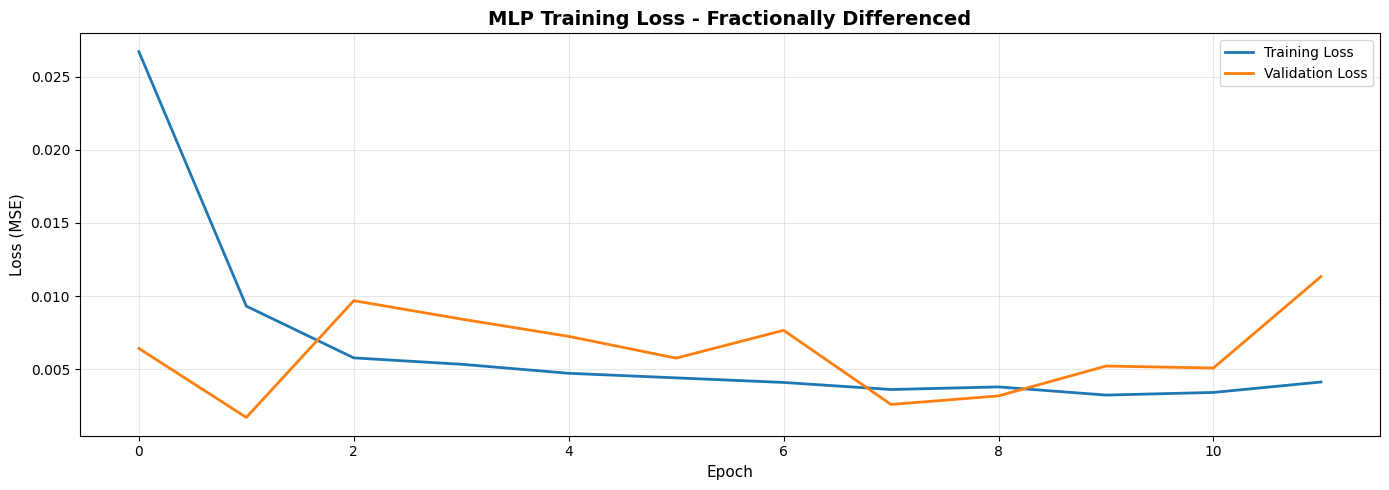

Saved: fig_16_mlp_fracdiff_predictions.png


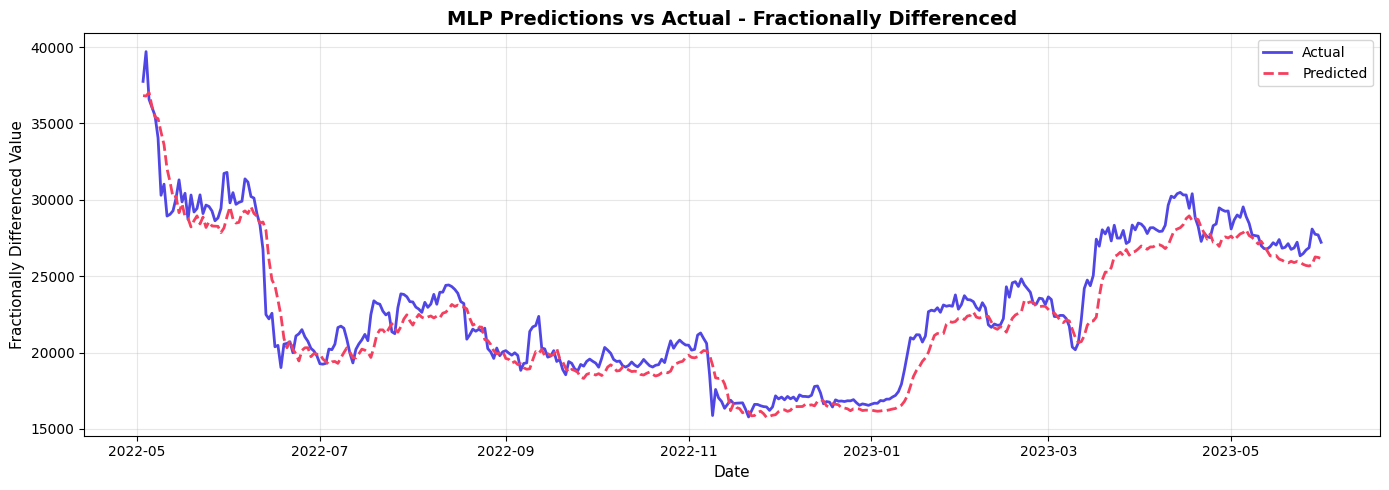


MLP PERFORMANCE METRICS - FRACTIONALLY DIFFERENCED
MSE:  1874047.79444148
RMSE: 1368.958653
MAE:  1059.632470
R-squared: 0.912650


In [10]:
# Step 2c: MLP on Fractionally Differenced Series
print("=" * 60)
print("STEP 2c: MLP MODEL ON FRACTIONALLY DIFFERENCED SERIES")
print("=" * 60)

# Prepare data for fractionally differenced series
X_frac, y_frac = create_mlp_data(frac_diff_series.values, window_size)
print(f"Input shape: {X_frac.shape}, Target shape: {y_frac.shape}")

# Train-test split
split_idx_frac = int(0.8 * len(X_frac))
X_train_frac, X_test_frac = X_frac[:split_idx_frac], X_frac[split_idx_frac:]
y_train_frac, y_test_frac = y_frac[:split_idx_frac], y_frac[split_idx_frac:]

# Scale data
scaler_frac_X = MinMaxScaler()
scaler_frac_y = MinMaxScaler()
X_train_frac_scaled = scaler_frac_X.fit_transform(X_train_frac)
X_test_frac_scaled = scaler_frac_X.transform(X_test_frac)
y_train_frac_scaled = scaler_frac_y.fit_transform(y_train_frac.reshape(-1, 1)).flatten()
y_test_frac_scaled = scaler_frac_y.transform(y_test_frac.reshape(-1, 1)).flatten()

print(f"Training samples: {len(X_train_frac_scaled)}, Test samples: {len(X_test_frac_scaled)}")

# Build MLP model (same architecture)
mlp_frac = Sequential([
    Dense(64, activation='relu', input_shape=(window_size,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
])

mlp_frac.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# Train model
history_frac = mlp_frac.fit(
    X_train_frac_scaled, y_train_frac_scaled,
    epochs=50, batch_size=32, validation_split=0.1,
    callbacks=[early_stop], verbose=0
)

print(f"Training completed. Best epoch: {np.argmin(history_frac.history['val_loss']) + 1}")

# Plot loss curve
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(history_frac.history['loss'], label='Training Loss', linewidth=2)
ax.plot(history_frac.history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss (MSE)', fontsize=11)
ax.set_title('MLP Training Loss - Fractionally Differenced', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_15_mlp_fracdiff_loss.png', bbox_inches='tight', dpi=150)
print("Saved: fig_15_mlp_fracdiff_loss.png")
plt.show()

# Make predictions
y_pred_frac_scaled = mlp_frac.predict(X_test_frac_scaled, verbose=0).flatten()
y_pred_frac = scaler_frac_y.inverse_transform(y_pred_frac_scaled.reshape(-1, 1)).flatten()

# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(14, 5))
test_index_frac = frac_diff_series.index[split_idx_frac + window_size:split_idx_frac + window_size + len(y_test_frac)]
ax.plot(test_index_frac, y_test_frac, label='Actual', linewidth=2, color='#4F46E5')
ax.plot(test_index_frac, y_pred_frac, label='Predicted', linewidth=2, color='#F43F5E', linestyle='--')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Fractionally Differenced Value', fontsize=11)
ax.set_title('MLP Predictions vs Actual - Fractionally Differenced', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_16_mlp_fracdiff_predictions.png', bbox_inches='tight', dpi=150)
print("Saved: fig_16_mlp_fracdiff_predictions.png")
plt.show()

# Calculate metrics
mse_frac = mean_squared_error(y_test_frac, y_pred_frac)
rmse_frac = np.sqrt(mse_frac)
mae_frac = mean_absolute_error(y_test_frac, y_pred_frac)
r2_frac = r2_score(y_test_frac, y_pred_frac)

print("\n" + "=" * 60)
print("MLP PERFORMANCE METRICS - FRACTIONALLY DIFFERENCED")
print("=" * 60)
print(f"MSE:  {mse_frac:.8f}")
print(f"RMSE: {rmse_frac:.6f}")
print(f"MAE:  {mae_frac:.6f}")
print(f"R-squared: {r2_frac:.6f}")

# Store metrics
mlp_metrics['FracDiff'] = {'MSE': mse_frac, 'RMSE': rmse_frac, 'MAE': mae_frac, 'R2': r2_frac}

In [11]:
# MLP Metrics Comparison
print("=" * 60)
print("MLP MODELS COMPARISON - ALL METRICS")
print("=" * 60)

mlp_comparison_df = pd.DataFrame(mlp_metrics).T
print(mlp_comparison_df.round(6))

# Store for PDF generation
mlp_metrics_for_pdf = mlp_comparison_df.copy()

MLP MODELS COMPARISON - ALL METRICS
                      MSE         RMSE          MAE        R2
Log-Returns  1.127000e-03     0.033573     0.023547 -0.161982
FracDiff     1.874048e+06  1368.958653  1059.632470  0.912650


# Step 3: Convolutional Neural Network (CNN) with Gramian Angular Field (GAF)

## GAF Transformation for All Three Series

STEP 3: GAF TRANSFORMATION
Creating GAF images for Price Levels...
GAF Levels - Images shape: (1953, 24, 24), Labels shape: (1953,)

Creating GAF images for Log-Returns...
GAF Log-Returns - Images shape: (1952, 24, 24), Labels shape: (1952,)

Creating GAF images for Fractionally Differenced...
GAF FracDiff - Images shape: (1953, 24, 24), Labels shape: (1953,)

Saved: fig_26_gaf_sample_levels.png


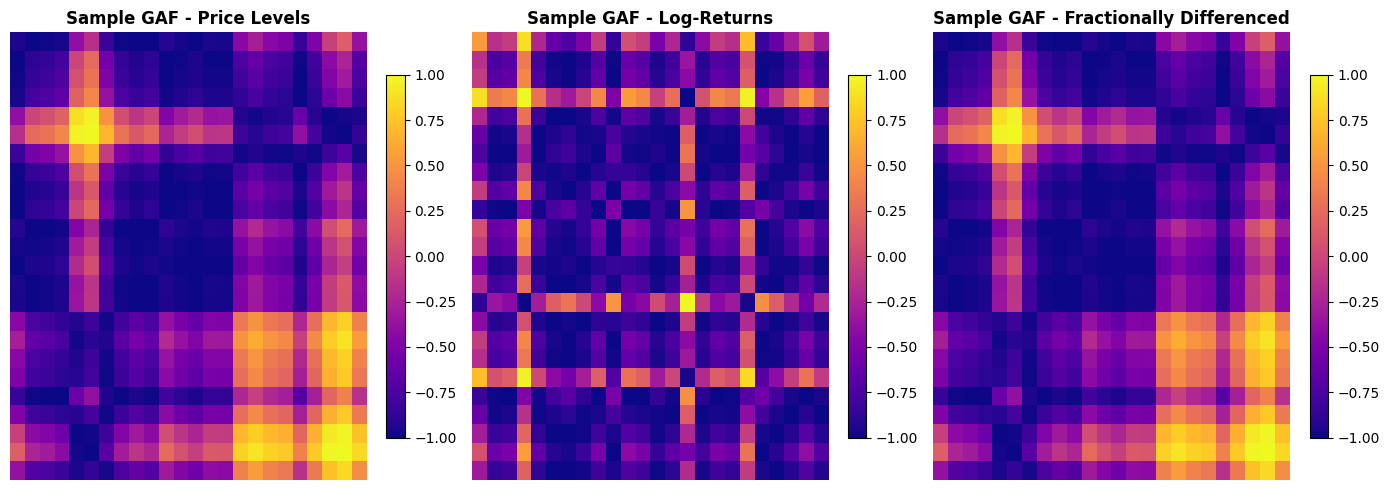

Saved: fig_27_gaf_sample_stationary.png


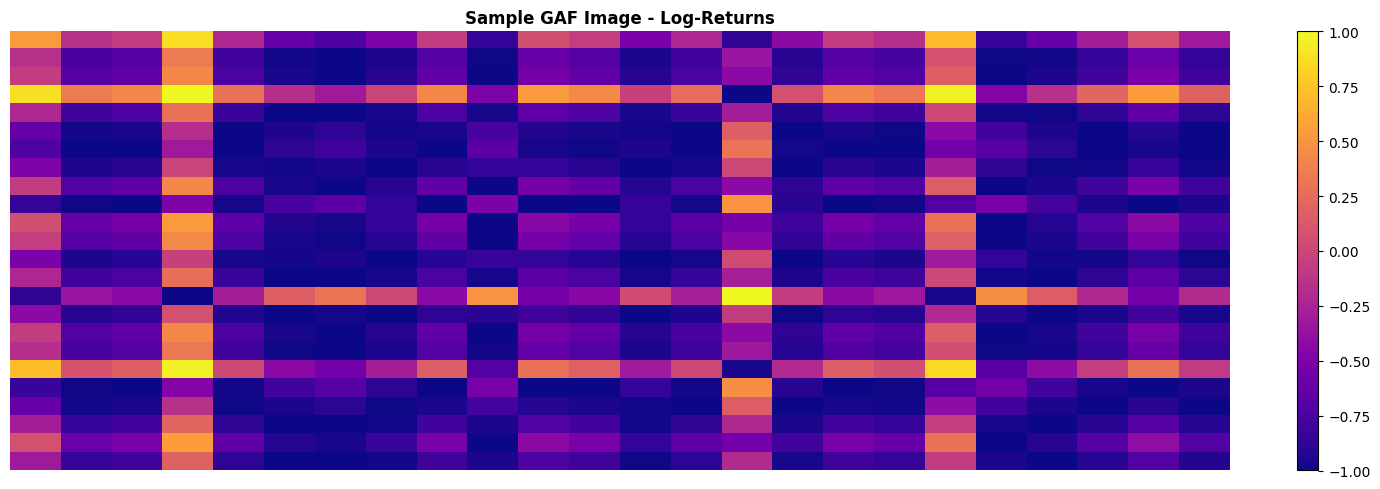

Saved: fig_28_gaf_sample_fracdiff.png


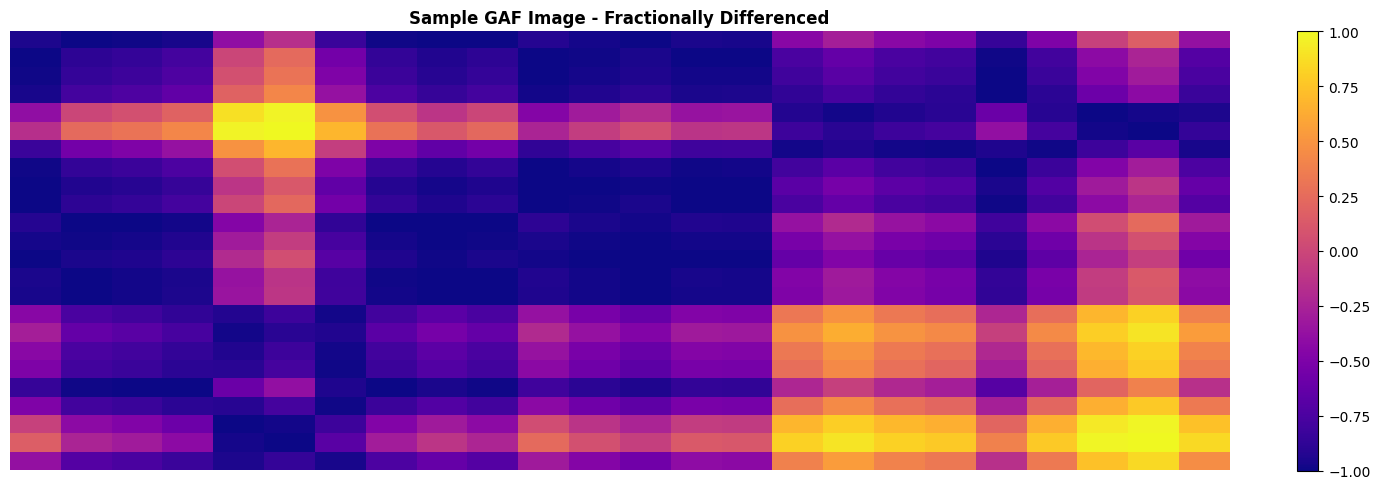

In [12]:
# Step 3: GAF Transformation
print("=" * 60)
print("STEP 3: GAF TRANSFORMATION")
print("=" * 60)

def create_gaf_data(series, window_size=24):
    """Create GAF images and binary labels from time series."""
    gaf = GramianAngularField(image_size=window_size, method='summation')

    X, y = [], []
    for i in range(len(series) - window_size):
        window = series[i:i + window_size]
        # Label: 1 if next value > current, else 0
        label = 1 if series[i + window_size] > series[i + window_size - 1] else 0

        # Reshape for GAF (needs 2D input)
        window_reshaped = window.reshape(1, -1)
        gaf_image = gaf.fit_transform(window_reshaped)

        X.append(gaf_image[0])
        y.append(label)

    return np.array(X), np.array(y)

# Apply GAF to all three series
print("Creating GAF images for Price Levels...")
X_gaf_levels, y_gaf_levels = create_gaf_data(close.values, window_size=24)
print(f"GAF Levels - Images shape: {X_gaf_levels.shape}, Labels shape: {y_gaf_levels.shape}")

print("\nCreating GAF images for Log-Returns...")
X_gaf_logret, y_gaf_logret = create_gaf_data(log_returns.values, window_size=24)
print(f"GAF Log-Returns - Images shape: {X_gaf_logret.shape}, Labels shape: {y_gaf_logret.shape}")

print("\nCreating GAF images for Fractionally Differenced...")
X_gaf_frac, y_gaf_frac = create_gaf_data(frac_diff_series.values, window_size=24)
print(f"GAF FracDiff - Images shape: {X_gaf_frac.shape}, Labels shape: {y_gaf_frac.shape}")

# Plot sample GAF images
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Sample from levels
im0 = axes[0].imshow(X_gaf_levels[0], cmap='plasma', aspect='auto')
axes[0].set_title('Sample GAF - Price Levels', fontsize=12, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Sample from log-returns
im1 = axes[1].imshow(X_gaf_logret[0], cmap='plasma', aspect='auto')
axes[1].set_title('Sample GAF - Log-Returns', fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Sample from fracdiff
im2 = axes[2].imshow(X_gaf_frac[0], cmap='plasma', aspect='auto')
axes[2].set_title('Sample GAF - Fractionally Differenced', fontsize=12, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.savefig('fig_26_gaf_sample_levels.png', bbox_inches='tight', dpi=150)
print("\nSaved: fig_26_gaf_sample_levels.png")
plt.show()

# Save individual GAF samples
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(X_gaf_logret[0], cmap='plasma', aspect='auto')
ax.set_title('Sample GAF Image - Log-Returns', fontsize=12, fontweight='bold')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig('fig_27_gaf_sample_stationary.png', bbox_inches='tight', dpi=150)
print("Saved: fig_27_gaf_sample_stationary.png")
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(X_gaf_frac[0], cmap='plasma', aspect='auto')
ax.set_title('Sample GAF Image - Fractionally Differenced', fontsize=12, fontweight='bold')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig('fig_28_gaf_sample_fracdiff.png', bbox_inches='tight', dpi=150)
print("Saved: fig_28_gaf_sample_fracdiff.png")
plt.show()

## Step 3a: CNN on Price Levels with GAF

In [13]:
# Step 3a: CNN on Levels
print("=" * 60)
print("STEP 3a: CNN MODEL ON PRICE LEVELS (GAF)")
print("=" * 60)

# Reshape for CNN (add channel dimension)
X_gaf_levels_cnn = X_gaf_levels.reshape(-1, 24, 24, 1)

# Train-test split
split_idx_cnn = int(0.8 * len(X_gaf_levels_cnn))
X_train_cnn_levels, X_test_cnn_levels = X_gaf_levels_cnn[:split_idx_cnn], X_gaf_levels_cnn[split_idx_cnn:]
y_train_cnn_levels, y_test_cnn_levels = y_gaf_levels[:split_idx_cnn], y_gaf_levels[split_idx_cnn:]

print(f"Training samples: {len(X_train_cnn_levels)}, Test samples: {len(X_test_cnn_levels)}")
print(f"Class distribution - Train: {np.bincount(y_train_cnn_levels)}, Test: {np.bincount(y_test_cnn_levels)}")

# Build CNN model
cnn_levels = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(24, 24, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_levels.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nCNN Model Architecture (Levels):")
cnn_levels.summary()

# Train model
early_stop_cnn = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_cnn_levels = cnn_levels.fit(
    X_train_cnn_levels, y_train_cnn_levels,
    epochs=30, batch_size=32, validation_split=0.1,
    callbacks=[early_stop_cnn], verbose=0
)

print(f"Training completed. Best epoch: {np.argmin(history_cnn_levels.history['val_loss']) + 1}")

STEP 3a: CNN MODEL ON PRICE LEVELS (GAF)
Training samples: 1562, Test samples: 391
Class distribution - Train: [743 819], Test: [208 183]

CNN Model Architecture (Levels):


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 22, 22, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,481 (330.00 KB)

 Trainable params: 84,481 (330.00 KB)

 Non-trainable params: 0 (0.00 B)

Training completed. Best epoch: 2


Saved: fig_17_cnn_levels_loss_acc.png


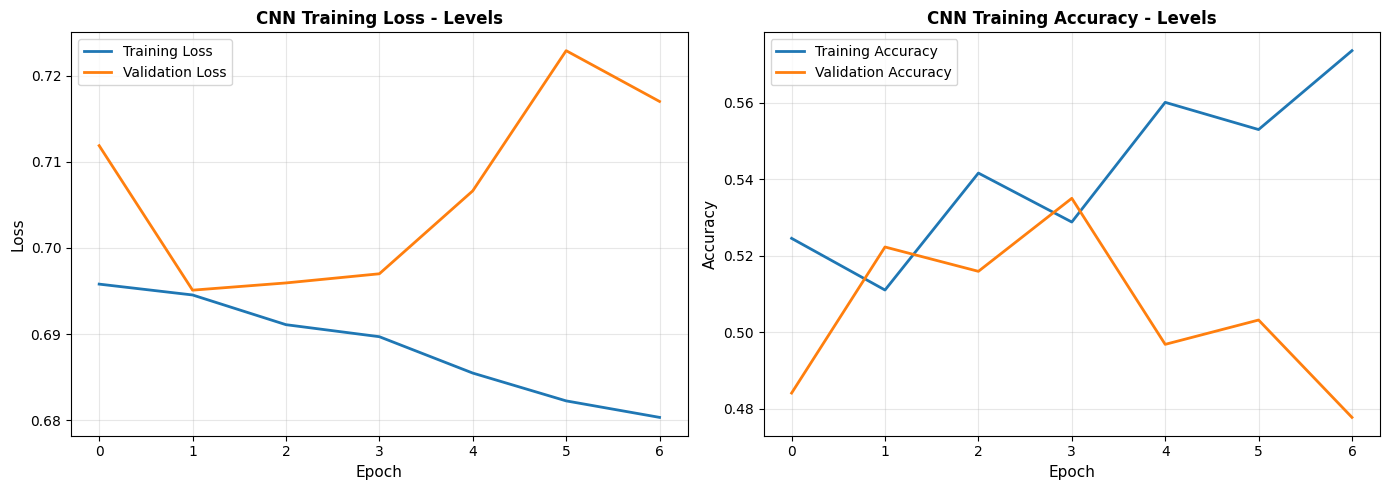

Saved: fig_18_cnn_levels_confusion.png


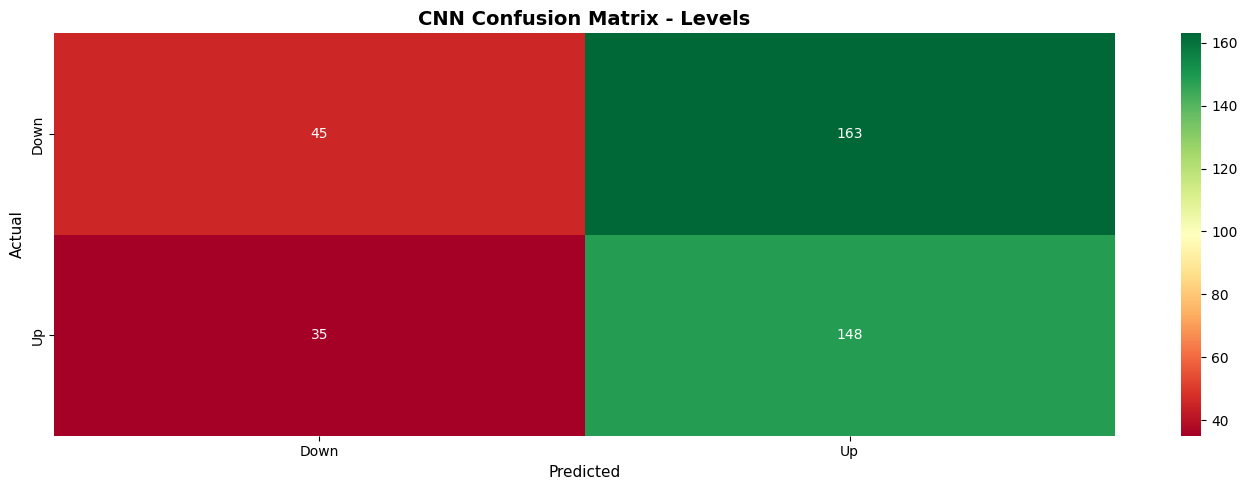

Saved: fig_19_cnn_levels_roc.png


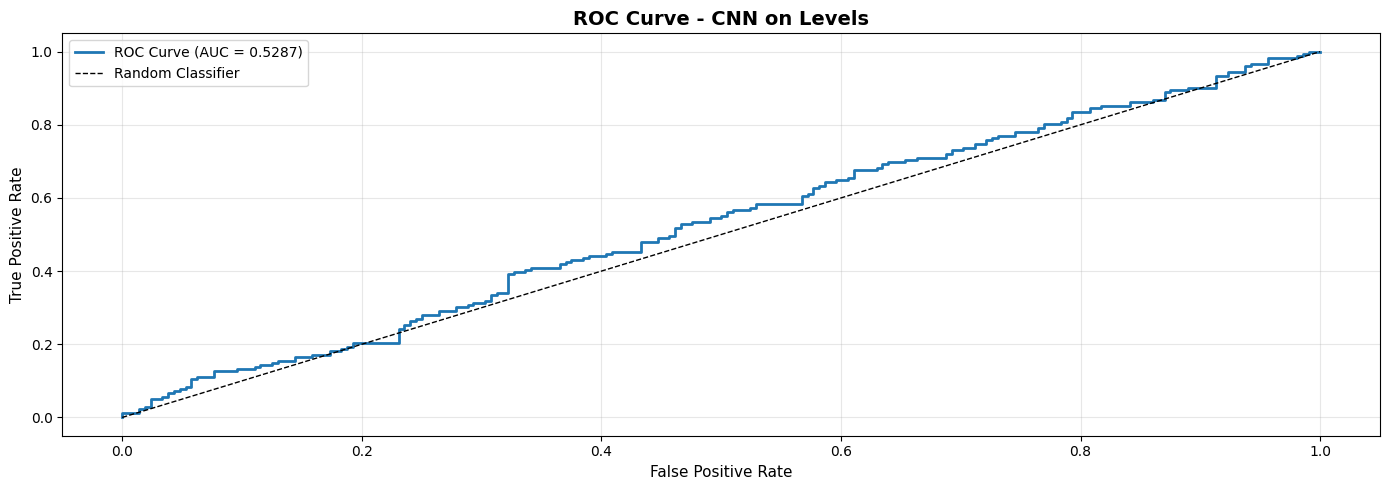


CNN PERFORMANCE METRICS - LEVELS
Accuracy:  0.4936
Precision: 0.4759
Recall:    0.8087
F1-Score:  0.5992
AUC-ROC:   0.5287


In [14]:
# Plot loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn_levels.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_cnn_levels.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('CNN Training Loss - Levels', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn_levels.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_cnn_levels.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('CNN Training Accuracy - Levels', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_17_cnn_levels_loss_acc.png', bbox_inches='tight', dpi=150)
print("Saved: fig_17_cnn_levels_loss_acc.png")
plt.show()

# Make predictions
y_pred_cnn_levels_prob = cnn_levels.predict(X_test_cnn_levels, verbose=0).flatten()
y_pred_cnn_levels = (y_pred_cnn_levels_prob > 0.5).astype(int)

# Confusion matrix
cm_levels = confusion_matrix(y_test_cnn_levels, y_pred_cnn_levels)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(cm_levels, annot=True, fmt='d', cmap='RdYlGn', ax=ax,
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title('CNN Confusion Matrix - Levels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_18_cnn_levels_confusion.png', bbox_inches='tight', dpi=150)
print("Saved: fig_18_cnn_levels_confusion.png")
plt.show()

# ROC Curve
fpr_levels, tpr_levels, _ = roc_curve(y_test_cnn_levels, y_pred_cnn_levels_prob)
auc_levels = roc_auc_score(y_test_cnn_levels, y_pred_cnn_levels_prob)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fpr_levels, tpr_levels, linewidth=2, label=f'ROC Curve (AUC = {auc_levels:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve - CNN on Levels', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_19_cnn_levels_roc.png', bbox_inches='tight', dpi=150)
print("Saved: fig_19_cnn_levels_roc.png")
plt.show()

# Calculate metrics
acc_levels = accuracy_score(y_test_cnn_levels, y_pred_cnn_levels)
prec_levels = precision_score(y_test_cnn_levels, y_pred_cnn_levels)
rec_levels = recall_score(y_test_cnn_levels, y_pred_cnn_levels)
f1_levels = f1_score(y_test_cnn_levels, y_pred_cnn_levels)

print("\n" + "=" * 60)
print("CNN PERFORMANCE METRICS - LEVELS")
print("=" * 60)
print(f"Accuracy:  {acc_levels:.4f}")
print(f"Precision: {prec_levels:.4f}")
print(f"Recall:    {rec_levels:.4f}")
print(f"F1-Score:  {f1_levels:.4f}")
print(f"AUC-ROC:   {auc_levels:.4f}")

# Store metrics
cnn_metrics = {
    'Levels': {'Accuracy': acc_levels, 'Precision': prec_levels, 'Recall': rec_levels, 'F1': f1_levels, 'AUC': auc_levels}
}

## Step 3b: MLP on Log-Returns with GAF

STEP 3b: MLP MODEL ON LOG-RETURNS (GAF)
Training samples: 1561, Test samples: 391
Class distribution - Train: [794 767], Test: [193 198]
MLP-GAF Model Architecture (Log-Returns):
Training completed. Best epoch: 33
Saved: fig_20_mlp_gaf_stationary_loss_acc.png


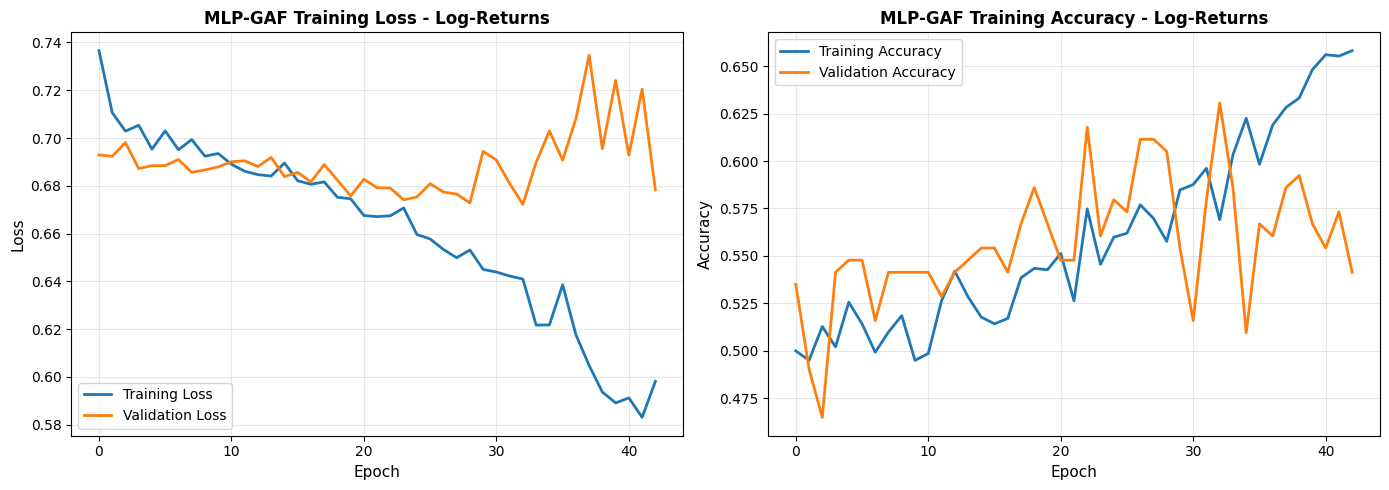

Saved: fig_21_mlp_gaf_stationary_confusion.png


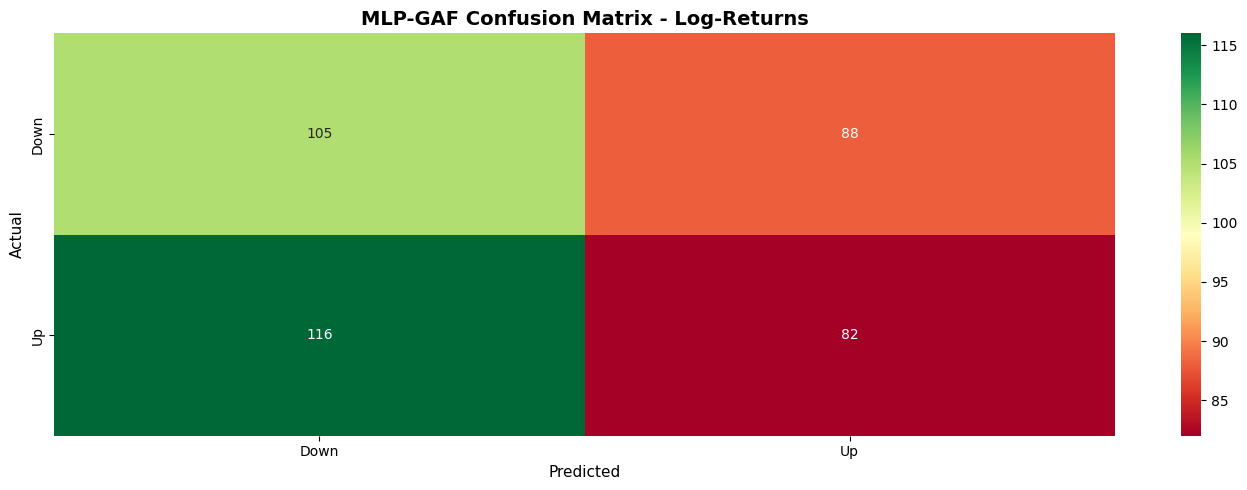

Saved: fig_22_mlp_gaf_stationary_roc.png


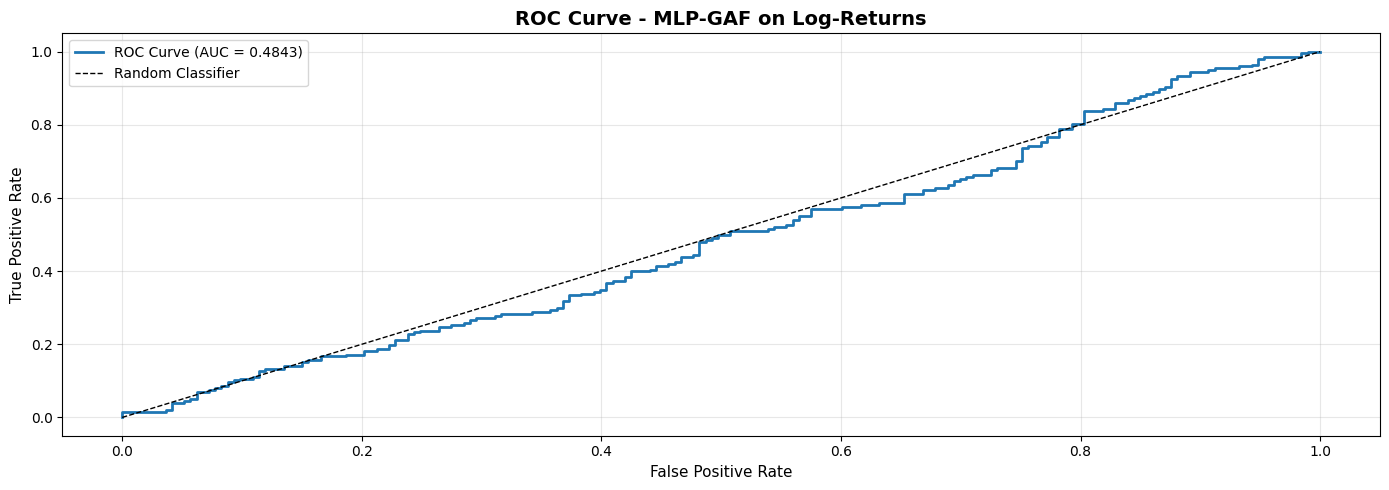


MLP-GAF PERFORMANCE METRICS - LOG-RETURNS
Accuracy:  0.4783
Precision: 0.4824
Recall:    0.4141
F1-Score:  0.4457
AUC-ROC:   0.4843


In [18]:
# Step 3b: MLP on Log-Returns (GAF)
print("=" * 60)
print("STEP 3b: MLP MODEL ON LOG-RETURNS (GAF)")
print("=" * 60)

# Flatten GAF images for MLP input (24x24 = 576 features)
X_gaf_logret_mlp = X_gaf_logret.reshape(len(X_gaf_logret), -1)

# Train-test split
split_idx_mlp_lr = int(0.8 * len(X_gaf_logret_mlp))
X_train_mlp_logret, X_test_mlp_logret = X_gaf_logret_mlp[:split_idx_mlp_lr], X_gaf_logret_mlp[split_idx_mlp_lr:]
y_train_mlp_logret, y_test_mlp_logret = y_gaf_logret[:split_idx_mlp_lr], y_gaf_logret[split_idx_mlp_lr:]

print(f"Training samples: {len(X_train_mlp_logret)}, Test samples: {len(X_test_mlp_logret)}")
print(f"Class distribution - Train: {np.bincount(y_train_mlp_logret)}, Test: {np.bincount(y_test_mlp_logret)}")

# Build MLP model on flattened GAF features
mlp_gaf_logret = Sequential([
    Dense(256, activation='relu', input_shape=(X_gaf_logret_mlp.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

mlp_gaf_logret.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("MLP-GAF Model Architecture (Log-Returns):")

# Train model
early_stop_mlp_gaf = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_mlp_logret = mlp_gaf_logret.fit(
    X_train_mlp_logret, y_train_mlp_logret,
    epochs=50, batch_size=32, validation_split=0.1,
    callbacks=[early_stop_mlp_gaf], verbose=0
)

print(f"Training completed. Best epoch: {np.argmin(history_mlp_logret.history['val_loss']) + 1}")

# Plot loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_mlp_logret.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_mlp_logret.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('MLP-GAF Training Loss - Log-Returns', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_mlp_logret.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_mlp_logret.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('MLP-GAF Training Accuracy - Log-Returns', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_20_mlp_gaf_stationary_loss_acc.png', bbox_inches='tight', dpi=150)
print("Saved: fig_20_mlp_gaf_stationary_loss_acc.png")
plt.show()

# Make predictions
y_pred_mlp_logret_prob = mlp_gaf_logret.predict(X_test_mlp_logret, verbose=0).flatten()
y_pred_mlp_logret = (y_pred_mlp_logret_prob > 0.5).astype(int)

# Confusion matrix
cm_mlp_logret = confusion_matrix(y_test_mlp_logret, y_pred_mlp_logret)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(cm_mlp_logret, annot=True, fmt='d', cmap='RdYlGn', ax=ax,
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title('MLP-GAF Confusion Matrix - Log-Returns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_21_mlp_gaf_stationary_confusion.png', bbox_inches='tight', dpi=150)
print("Saved: fig_21_mlp_gaf_stationary_confusion.png")
plt.show()

# ROC Curve
fpr_mlp_logret, tpr_mlp_logret, _ = roc_curve(y_test_mlp_logret, y_pred_mlp_logret_prob)
auc_mlp_logret = roc_auc_score(y_test_mlp_logret, y_pred_mlp_logret_prob)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fpr_mlp_logret, tpr_mlp_logret, linewidth=2, label=f'ROC Curve (AUC = {auc_mlp_logret:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve - MLP-GAF on Log-Returns', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_22_mlp_gaf_stationary_roc.png', bbox_inches='tight', dpi=150)
print("Saved: fig_22_mlp_gaf_stationary_roc.png")
plt.show()

# Calculate metrics
acc_mlp_logret = accuracy_score(y_test_mlp_logret, y_pred_mlp_logret)
prec_mlp_logret = precision_score(y_test_mlp_logret, y_pred_mlp_logret)
rec_mlp_logret = recall_score(y_test_mlp_logret, y_pred_mlp_logret)
f1_mlp_logret = f1_score(y_test_mlp_logret, y_pred_mlp_logret)

print("\n" + "=" * 60)
print("MLP-GAF PERFORMANCE METRICS - LOG-RETURNS")
print("=" * 60)
print(f"Accuracy:  {acc_mlp_logret:.4f}")
print(f"Precision: {prec_mlp_logret:.4f}")
print(f"Recall:    {rec_mlp_logret:.4f}")
print(f"F1-Score:  {f1_mlp_logret:.4f}")
print(f"AUC-ROC:   {auc_mlp_logret:.4f}")

# Store metrics
cnn_metrics['Log-Returns'] = {'Accuracy': acc_mlp_logret, 'Precision': prec_mlp_logret, 'Recall': rec_mlp_logret, 'F1': f1_mlp_logret, 'AUC': auc_mlp_logret}


## Step 3c: CNN on Fractionally Differenced with GAF

STEP 3c: CNN MODEL ON FRACTIONALLY DIFFERENCED (GAF)
Training samples: 1562, Test samples: 391
Class distribution - Train: [743 819], Test: [208 183]
Training completed. Best epoch: 3
Saved: fig_23_cnn_fracdiff_loss_acc.png


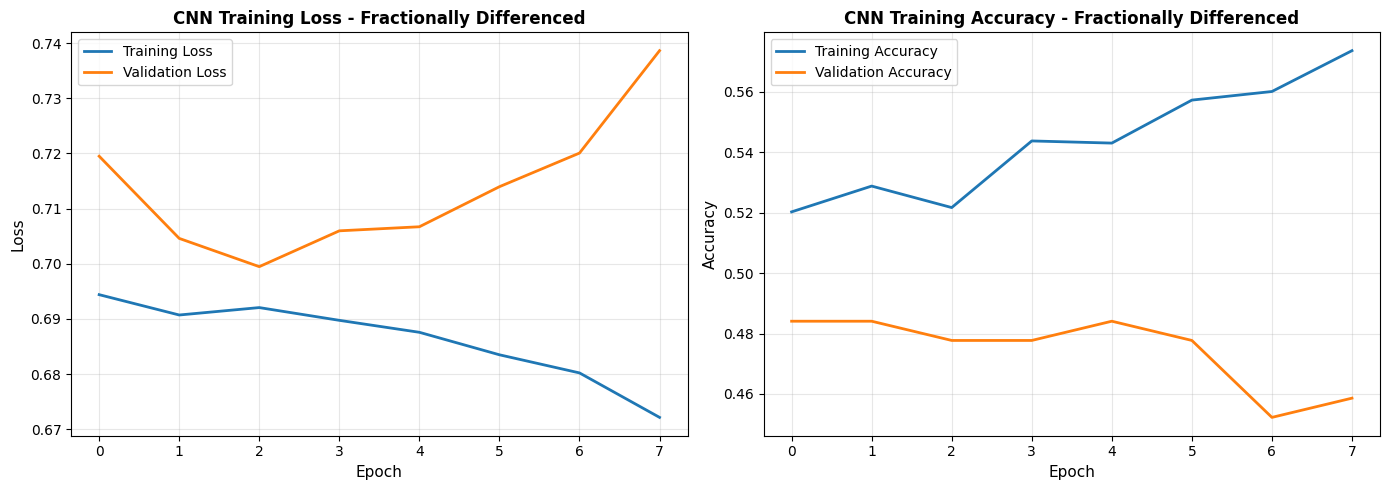

Saved: fig_24_cnn_fracdiff_confusion.png


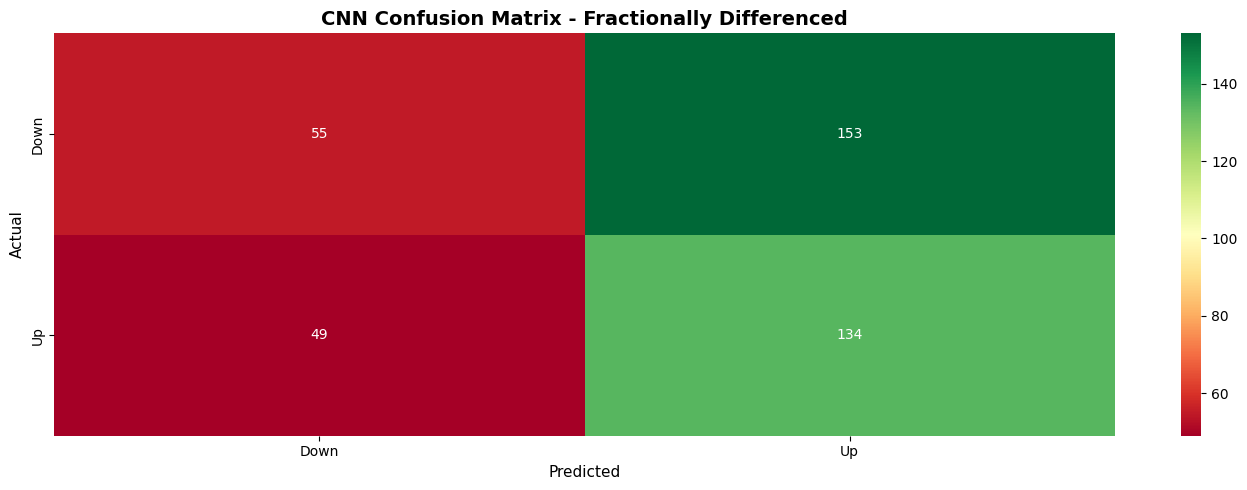

Saved: fig_25_cnn_fracdiff_roc.png


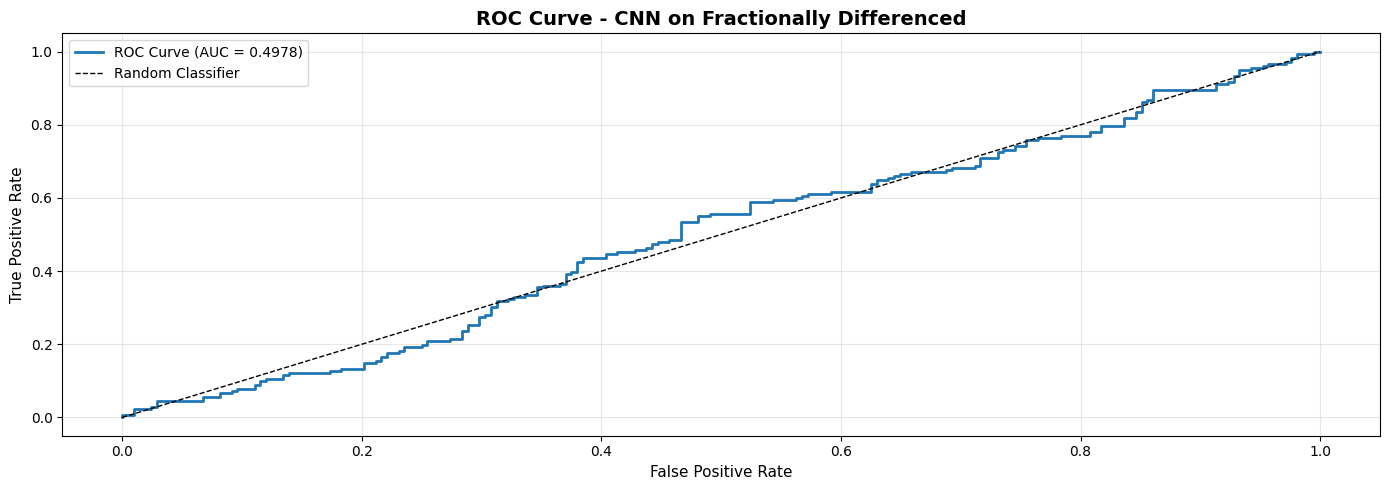


CNN PERFORMANCE METRICS - FRACTIONALLY DIFFERENCED
Accuracy:  0.4834
Precision: 0.4669
Recall:    0.7322
F1-Score:  0.5702
AUC-ROC:   0.4978


In [19]:
# Step 3c: CNN on Fractionally Differenced
print("=" * 60)
print("STEP 3c: CNN MODEL ON FRACTIONALLY DIFFERENCED (GAF)")
print("=" * 60)

# Reshape for CNN
X_gaf_frac_cnn = X_gaf_frac.reshape(-1, 24, 24, 1)

# Train-test split
split_idx_cnn_frac = int(0.8 * len(X_gaf_frac_cnn))
X_train_cnn_frac, X_test_cnn_frac = X_gaf_frac_cnn[:split_idx_cnn_frac], X_gaf_frac_cnn[split_idx_cnn_frac:]
y_train_cnn_frac, y_test_cnn_frac = y_gaf_frac[:split_idx_cnn_frac], y_gaf_frac[split_idx_cnn_frac:]

print(f"Training samples: {len(X_train_cnn_frac)}, Test samples: {len(X_test_cnn_frac)}")
print(f"Class distribution - Train: {np.bincount(y_train_cnn_frac)}, Test: {np.bincount(y_test_cnn_frac)}")

# Build CNN model (same architecture)
cnn_frac = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(24, 24, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_frac.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history_cnn_frac = cnn_frac.fit(
    X_train_cnn_frac, y_train_cnn_frac,
    epochs=30, batch_size=32, validation_split=0.1,
    callbacks=[early_stop_cnn], verbose=0
)

print(f"Training completed. Best epoch: {np.argmin(history_cnn_frac.history['val_loss']) + 1}")

# Plot loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn_frac.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_cnn_frac.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('CNN Training Loss - Fractionally Differenced', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn_frac.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_cnn_frac.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('CNN Training Accuracy - Fractionally Differenced', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_23_cnn_fracdiff_loss_acc.png', bbox_inches='tight', dpi=150)
print("Saved: fig_23_cnn_fracdiff_loss_acc.png")
plt.show()

# Make predictions
y_pred_cnn_frac_prob = cnn_frac.predict(X_test_cnn_frac, verbose=0).flatten()
y_pred_cnn_frac = (y_pred_cnn_frac_prob > 0.5).astype(int)

# Confusion matrix
cm_frac = confusion_matrix(y_test_cnn_frac, y_pred_cnn_frac)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(cm_frac, annot=True, fmt='d', cmap='RdYlGn', ax=ax,
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title('CNN Confusion Matrix - Fractionally Differenced', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_24_cnn_fracdiff_confusion.png', bbox_inches='tight', dpi=150)
print("Saved: fig_24_cnn_fracdiff_confusion.png")
plt.show()

# ROC Curve
fpr_frac, tpr_frac, _ = roc_curve(y_test_cnn_frac, y_pred_cnn_frac_prob)
auc_frac = roc_auc_score(y_test_cnn_frac, y_pred_cnn_frac_prob)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fpr_frac, tpr_frac, linewidth=2, label=f'ROC Curve (AUC = {auc_frac:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve - CNN on Fractionally Differenced', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_25_cnn_fracdiff_roc.png', bbox_inches='tight', dpi=150)
print("Saved: fig_25_cnn_fracdiff_roc.png")
plt.show()

# Calculate metrics
acc_frac = accuracy_score(y_test_cnn_frac, y_pred_cnn_frac)
prec_frac = precision_score(y_test_cnn_frac, y_pred_cnn_frac)
rec_frac = recall_score(y_test_cnn_frac, y_pred_cnn_frac)
f1_frac = f1_score(y_test_cnn_frac, y_pred_cnn_frac)

print("\n" + "=" * 60)
print("CNN PERFORMANCE METRICS - FRACTIONALLY DIFFERENCED")
print("=" * 60)
print(f"Accuracy:  {acc_frac:.4f}")
print(f"Precision: {prec_frac:.4f}")
print(f"Recall:    {rec_frac:.4f}")
print(f"F1-Score:  {f1_frac:.4f}")
print(f"AUC-ROC:   {auc_frac:.4f}")

# Store metrics
cnn_metrics['FracDiff'] = {'Accuracy': acc_frac, 'Precision': prec_frac, 'Recall': rec_frac, 'F1': f1_frac, 'AUC': auc_frac}

In [20]:
# CNN Metrics Comparison
print("=" * 60)
print("CNN MODELS COMPARISON - ALL METRICS")
print("=" * 60)

cnn_comparison_df = pd.DataFrame(cnn_metrics).T
print(cnn_comparison_df.round(4))

# Store for PDF generation
cnn_metrics_for_pdf = cnn_comparison_df.copy()

CNN MODELS COMPARISON - ALL METRICS
             Accuracy  Precision  Recall      F1     AUC
Levels         0.4936     0.4759  0.8087  0.5992  0.5287
Log-Returns    0.4783     0.4824  0.4141  0.4457  0.4843
FracDiff       0.4834     0.4669  0.7322  0.5702  0.4978


## Step 3d: CNN Evaluation and Discussion

# Step 4: CNN vs MLP Architecture Comparison

In [21]:
# Step 4: Summary Comparison Table - CNN vs MLP
print("=" * 70)
print("STEP 4: CNN vs MLP ARCHITECTURE COMPARISON SUMMARY")
print("=" * 70)

summary_data = {
    "Feature": [
        "Input Format",
        "Spatial Awareness",
        "Best Task",
        "Best Input Representation",
        "Computational Cost",
        "Interpretability"
    ],
    "MLP": [
        "Flat vector (lags or flattened GAF)",
        "None - treats all features equally",
        "Regression (continuous forecasting)",
        "Log-returns or fractional differencing",
        "Low",
        "Higher"
    ],
    "CNN": [
        "2D GAF image (24x24)",
        "Local pattern detection via filters",
        "Classification (direction prediction)",
        "Fractional differencing",
        "Higher",
        "Lower"
    ]
}

df_summary = pd.DataFrame(summary_data)
df_summary.set_index("Feature", inplace=True)
print(df_summary.to_string())


STEP 4: CNN vs MLP ARCHITECTURE COMPARISON SUMMARY
                                                              MLP                                    CNN
Feature                                                                                                 
Input Format                  Flat vector (lags or flattened GAF)                   2D GAF image (24x24)
Spatial Awareness              None - treats all features equally    Local pattern detection via filters
Best Task                     Regression (continuous forecasting)  Classification (direction prediction)
Best Input Representation  Log-returns or fractional differencing                Fractional differencing
Computational Cost                                            Low                                 Higher
Interpretability                                           Higher                                  Lower
